# N02A — OAI-Only Primary Concept Bottleneck Development

**Research question.** Can the primary ConvNeXt-Tiny concept bottleneck model be developed and frozen using OAI only?

**Default mode.** Validate existing checkpoints. Retraining is allowed only when a required checkpoint is missing or fails its integrity gate.

**Important.** The checkpoint protocol name remains `N03_FINAL_V4_DRIVE_SAFE` because the weights were created by the earlier executed pipeline. Renaming a protocol does not change the model and would break provenance.


## Reader Guide

**Pipeline role:** Develops and freezes the three-seed primary concept-bottleneck ensemble using OAI only.

**Protection boundary:** NHANES must not be accessed for training, validation, or model selection. **Produces:** frozen checkpoints, validation-only temperatures, OAI test predictions, and model manifests.

**Artifact naming note:** frozen outputs retain `N03` identifiers from the earlier executed checkpoint protocol. This is an immutable provenance label, not an additional pipeline stage.

# 0. Frozen protocol

1. **ConvNeXt-Tiny is predefined.** No backbone comparison is performed in N03.
2. **ImageNet initialization is fixed.**
3. **Input size is fixed at 320 × 320.**
4. **The OAI split is patient-level and frozen before training.**
5. **Three training seeds are generated deterministically from the frozen study seed.**
6. **Every predeclared seed is trained and reported.**
7. **No weak seed may be replaced, hidden, or excluded because of its result.**
8. **The weighted sampler from the collapsed experiment is prohibited.**
9. **Moderate class weights are applied once, inside the losses.**
10. **The encoder is initially frozen, then fine-tuned using a lower encoder learning rate.**
11. **The concept-to-KL mapping is trained primarily from true one-hot concepts.**
12. **A smaller predicted-concept mapping loss teaches deployable end-to-end behavior.**
13. **Early stopping cannot occur before the minimum training period.**
14. **Underfitting, overfitting, and output collapse are explicit failure conditions.**
15. **Calibration uses OAI validation only.**
16. **The final ensemble is the equal arithmetic mean of all three eligible seeds.**
17. **NHANES is never used for fitting, early stopping, model selection, calibration, or seed selection.**
18. **NHANES metrics are not computed or displayed in N03.**
19. **Paper mode requires CUDA.**
20. **The notebook passes only after every required artifact is verified on Google Drive.**
21. **Colab DataLoaders use `num_workers=0` to avoid multiprocessing cleanup failures.**
22. **History and a resumable last-state checkpoint are saved after every completed epoch.**
23. **Gradient norm, GPU memory, calibration error, MAE, accuracy, learning rate, and epoch time are logged live.**
24. **Validation performance is reported after one-, two-, and three-seed ensembling.**
25. **Isolated AMP overflows are skipped and logged; the run fails only if non-finite gradients exceed the predefined persistence threshold.**
26. **PyTorch checkpoints are written through local staging and verified Drive copies; direct `.pt.tmp` renames on Google Drive are prohibited.**

In [2]:



from pathlib import Path

import sys



IN_COLAB = "google.colab" in sys.modules



if IN_COLAB:

    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)



PROJECT_ROOT = Path("/content/drive/MyDrive/Master Thesis")



if not PROJECT_ROOT.exists():

    raise FileNotFoundError(

        "Google Drive project root is unavailable:\n"

        f"{PROJECT_ROOT}"

    )



THESIS_ROOT = PROJECT_ROOT / "thesis"

RESULTS_ROOT = THESIS_ROOT / "results"

FIGURES_ROOT = THESIS_ROOT / "figures"

TABLES_ROOT = THESIS_ROOT / "tables"

MANIFESTS = THESIS_ROOT / "manifests"

NOTEBOOKS_ROOT = THESIS_ROOT / "notebooks"

CHECKPOINTS_ROOT = THESIS_ROOT / "checkpoints"

PREDICTIONS_ROOT = THESIS_ROOT / "predictions"



STAGE = "N03"

RESULTS = RESULTS_ROOT / STAGE

FIGURES = FIGURES_ROOT / STAGE

TABLES = TABLES_ROOT / STAGE

CHECKPOINTS = CHECKPOINTS_ROOT / STAGE

PREDICTIONS = PREDICTIONS_ROOT / STAGE



for folder in (

    THESIS_ROOT,

    RESULTS_ROOT,

    FIGURES_ROOT,

    TABLES_ROOT,

    MANIFESTS,

    NOTEBOOKS_ROOT,

    CHECKPOINTS_ROOT,

    PREDICTIONS_ROOT,

    RESULTS,

    FIGURES,

    TABLES,

    CHECKPOINTS,

    PREDICTIONS,

):

    folder.mkdir(parents=True, exist_ok=True)



write_test = THESIS_ROOT / ".n03_write_test"

write_test.write_text("N03", encoding="utf-8")

if not write_test.exists():

    raise RuntimeError("Google Drive is not writable.")

write_test.unlink()



print("PROJECT_ROOT:", PROJECT_ROOT)

print("RESULTS:", RESULTS)

print("CHECKPOINTS:", CHECKPOINTS)

print("PREDICTIONS:", PREDICTIONS)

print("Drive write preflight: PASS")

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Master Thesis
RESULTS: /content/drive/MyDrive/Master Thesis/thesis/results/N03
CHECKPOINTS: /content/drive/MyDrive/Master Thesis/thesis/checkpoints/N03
PREDICTIONS: /content/drive/MyDrive/Master Thesis/thesis/predictions/N03
Drive write preflight: PASS


In [3]:



import hashlib

import importlib

import json

import math

import os

import platform

import random

import re

import shutil

import subprocess

import sys

import textwrap

import uuid

import time

import tempfile

from dataclasses import asdict, dataclass

from datetime import datetime, timezone

from time import perf_counter

from typing import Any



def ensure_package(package_name: str, import_name: str | None = None) -> None:

    module_name = import_name or package_name

    try:

        importlib.import_module(module_name)

    except ImportError:

        subprocess.check_call([

            sys.executable,

            "-m",

            "pip",

            "install",

            "-q",

            package_name,

        ])



ensure_package("timm")



import matplotlib as mpl

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from PIL import Image, ImageOps

from sklearn.metrics import (

    accuracy_score,

    balanced_accuracy_score,

    cohen_kappa_score,

    confusion_matrix,

    f1_score,

    log_loss,

    mean_absolute_error,

    mean_squared_error,

    recall_score,

)

from sklearn.model_selection import StratifiedShuffleSplit

import timm

import torch

from torch import nn

import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset

from torchvision import transforms

from tqdm.auto import tqdm



RUN_MODE = os.environ.get("N03_RUN_MODE", "paper").strip().lower()

if RUN_MODE not in {"paper", "smoke"}:

    raise ValueError("N03_RUN_MODE must be 'paper' or 'smoke'.")



@dataclass(frozen=True)

class N03Config:

    study_seed: int = 20260803

    primary_backbone: str = "convnext_tiny.fb_in1k"

    image_size: int = 320

    train_fraction: float = 0.60

    validation_fraction: float = 0.20

    test_fraction: float = 0.20

    split_seed: int = 20260803



    epochs_paper: int = 35

    epochs_smoke: int = 3

    frozen_encoder_epochs: int = 2

    minimum_epochs_before_stopping: int = 12

    patience_paper: int = 8

    patience_smoke: int = 2



    batch_size_a100: int = 24

    batch_size_other_gpu: int = 12



    num_workers: int = 0

    encoder_learning_rate: float = 2e-5

    head_learning_rate: float = 2e-4

    weight_decay: float = 1e-4



    concept_loss_weight: float = 1.0

    true_mapping_loss_weight: float = 1.0

    predicted_mapping_loss_weight_start: float = 0.05

    predicted_mapping_loss_weight_end: float = 0.35

    direct_kl_loss_weight: float = 0.20



    label_smoothing: float = 0.02

    gradient_clip_norm: float = 5.0

    minimum_validation_patients: int = 100

    train_monitor_size: int = 1000



    severe_underfit_qwk: float = 0.10

    severe_underfit_concept_f1: float = 0.12

    severe_overfit_qwk_gap: float = 0.25

    collapse_minimum_predicted_kl_classes: int = 3

    collapse_minimum_predicted_concept_classes: int = 2



    temperature_max_iter: int = 100

    prediction_batch_size_multiplier: int = 2

    ece_bins: int = 15

    resume_training: bool = True

    protocol_version: str = "N03_FINAL_V4_DRIVE_SAFE"

    maximum_nonfinite_gradient_steps_per_epoch: int = 8

    maximum_nonfinite_gradient_fraction: float = 0.05



CONFIG = N03Config()



if CONFIG.split_seed != CONFIG.study_seed:

    raise RuntimeError(

        "The frozen split seed must equal the frozen study seed."

    )



seed_sequence = np.random.SeedSequence(

    CONFIG.study_seed

)



TRAINING_SEEDS = tuple(

    int(child.generate_state(1)[0])

    for child in seed_sequence.spawn(3)

)



if len(set(TRAINING_SEEDS)) != 3:

    raise RuntimeError(

        "Deterministic seed generation did not produce three unique seeds."

    )



EPOCHS = (

    CONFIG.epochs_paper

    if RUN_MODE == "paper"

    else CONFIG.epochs_smoke

)

PATIENCE = (

    CONFIG.patience_paper

    if RUN_MODE == "paper"

    else CONFIG.patience_smoke

)



DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU_NAME = (

    torch.cuda.get_device_name(0)

    if torch.cuda.is_available()

    else "CPU"

)



if RUN_MODE == "paper" and DEVICE.type != "cuda":

    raise RuntimeError(

        "N03 paper mode requires a CUDA GPU. "

        "Switch Colab to a GPU runtime."

    )



AMP_ENABLED = DEVICE.type == "cuda"

PIN_MEMORY = DEVICE.type == "cuda"






if DEVICE.type == "cuda":

    BATCH_SIZE = (

        CONFIG.batch_size_a100

        if "A100" in GPU_NAME.upper()

        else CONFIG.batch_size_other_gpu

    )

else:

    BATCH_SIZE = 2



GRADIENT_ACCUMULATION = 1

EFFECTIVE_BATCH_SIZE = (

    BATCH_SIZE * GRADIENT_ACCUMULATION

)



if BATCH_SIZE < 1:

    raise RuntimeError("Resolved batch size must be positive.")



if GRADIENT_ACCUMULATION < 1:

    raise RuntimeError(

        "Gradient accumulation must be positive."

    )



print("Run mode:", RUN_MODE)

print("Device:", DEVICE)

print("Accelerator:", GPU_NAME)

print("Epoch limit:", EPOCHS)

print("Batch size:", BATCH_SIZE)

print("Gradient accumulation:", GRADIENT_ACCUMULATION)

print("Effective batch size:", EFFECTIVE_BATCH_SIZE)

print("DataLoader workers:", CONFIG.num_workers)

print("Resume training:", CONFIG.resume_training)

print("Protocol version:", CONFIG.protocol_version)

print("Frozen backbone:", CONFIG.primary_backbone)

print("Frozen study seed:", CONFIG.study_seed)

print("Deterministic training seeds:", TRAINING_SEEDS)



if RUN_MODE == "paper" and "A100" not in GPU_NAME.upper():

    print(

        "NOTE: ConvNeXt-Tiny can run on this GPU. An A100 is recommended "

        "only for faster completion."

    )


Run mode: paper
Device: cuda
Accelerator: NVIDIA A100-SXM4-80GB
Epoch limit: 35
Batch size: 24
Gradient accumulation: 1
Effective batch size: 24
DataLoader workers: 0
Resume training: True
Protocol version: N03_FINAL_V4_DRIVE_SAFE
Frozen backbone: convnext_tiny.fb_in1k
Frozen study seed: 20260803
Deterministic training seeds: (367761876, 1767922150, 1023912954)


In [4]:



def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:

    digest = hashlib.sha256()

    with path.open("rb") as handle:

        for block in iter(lambda: handle.read(chunk_size), b""):

            digest.update(block)

    return digest.hexdigest()



def atomic_csv(frame: pd.DataFrame, path: Path) -> None:

    path.parent.mkdir(parents=True, exist_ok=True)

    temporary = path.with_suffix(path.suffix + ".tmp")

    frame.to_csv(temporary, index=False)

    temporary.replace(path)



def atomic_json(payload: dict[str, Any], path: Path) -> None:

    path.parent.mkdir(parents=True, exist_ok=True)

    temporary = path.with_suffix(path.suffix + ".tmp")

    temporary.write_text(json.dumps(payload, indent=2), encoding="utf-8")

    temporary.replace(path)



def robust_torch_save(

    payload: dict[str, Any],

    destination: Path,

    retries: int = 8,

    retry_seconds: float = 1.0,

) -> None:

    """

    Save locally first, then copy the completed archive to Google Drive.

    This avoids Drive-FUSE visibility races after torch.save().

    """

    destination = Path(destination)

    destination.parent.mkdir(parents=True, exist_ok=True)



    local_directory = Path("/content/n03_checkpoint_staging")

    local_directory.mkdir(parents=True, exist_ok=True)



    token = uuid.uuid4().hex

    local_path = local_directory / f"{destination.name}.{token}.local"

    drive_staging = destination.with_name(

        f".{destination.name}.{token}.uploading"

    )



    try:

        torch.save(payload, local_path)



        if not local_path.exists() or local_path.stat().st_size == 0:

            raise IOError(

                f"Local checkpoint was not created correctly: {local_path}"

            )



        shutil.copyfile(local_path, drive_staging)



        for attempt in range(1, retries + 1):

            if (

                drive_staging.exists()

                and drive_staging.stat().st_size

                == local_path.stat().st_size

            ):

                break

            if attempt == retries:

                raise FileNotFoundError(

                    "Drive did not expose the staged checkpoint: "

                    f"{drive_staging}"

                )

            time.sleep(retry_seconds)



        renamed = False

        for _ in range(retries):

            try:

                os.replace(drive_staging, destination)

                renamed = True

                break

            except (FileNotFoundError, OSError):

                time.sleep(retry_seconds)



        if not renamed:

            shutil.copyfile(local_path, destination)



        for attempt in range(1, retries + 1):

            if (

                destination.exists()

                and destination.stat().st_size

                == local_path.stat().st_size

            ):

                break

            if attempt == retries:

                raise IOError(

                    "Checkpoint verification failed after Drive copy: "

                    f"{destination}"

                )

            time.sleep(retry_seconds)



    finally:

        for path in (local_path, drive_staging):

            try:

                if path.exists():

                    path.unlink()

            except OSError:

                pass





def robust_torch_load(

    source: Path,

    map_location: Any,

) -> dict[str, Any]:

    """

    Copy a Drive checkpoint locally before torch.load().

    """

    source = Path(source)



    if not source.exists() or source.stat().st_size == 0:

        raise FileNotFoundError(

            f"Checkpoint is missing or empty: {source}"

        )



    local_directory = Path("/content/n03_checkpoint_staging")

    local_directory.mkdir(parents=True, exist_ok=True)

    local_path = local_directory / f"{source.name}.{uuid.uuid4().hex}.read"



    try:

        shutil.copyfile(source, local_path)

        return torch.load(

            local_path,

            map_location=map_location,

            weights_only=False,

        )

    finally:

        try:

            if local_path.exists():

                local_path.unlink()

        except OSError:

            pass



def set_global_seed(seed: int) -> None:

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)



def seed_worker(worker_id: int) -> None:

    worker_seed = torch.initial_seed() % (2**32)

    np.random.seed(worker_seed)

    random.seed(worker_seed)



N01_STATUS = RESULTS_ROOT / "N01" / "n01_status.json"

N01_OAI_COHORT = RESULTS_ROOT / "N01" / "n01_oai_cohort.csv"

N02_STATUS = RESULTS_ROOT / "N02" / "n02_status.json"



for required_path in (

    N01_STATUS,

    N01_OAI_COHORT,

):

    if not required_path.exists():

        raise FileNotFoundError(required_path)



n01_status = json.loads(N01_STATUS.read_text(encoding="utf-8"))

if n01_status.get("passed") is not True:

    raise RuntimeError("N01 has not passed. N03 cannot continue.")



n02_record = None

if N02_STATUS.exists():

    n02_record = json.loads(N02_STATUS.read_text(encoding="utf-8"))



required_runtime_globals = {

    "CONFIG": CONFIG,

    "TRAINING_SEEDS": TRAINING_SEEDS,

    "DEVICE": DEVICE,

    "GPU_NAME": GPU_NAME,

    "EPOCHS": EPOCHS,

    "PATIENCE": PATIENCE,

    "BATCH_SIZE": BATCH_SIZE,

    "GRADIENT_ACCUMULATION": GRADIENT_ACCUMULATION,

    "EFFECTIVE_BATCH_SIZE": EFFECTIVE_BATCH_SIZE,

    "AMP_ENABLED": AMP_ENABLED,

    "PIN_MEMORY": PIN_MEMORY,

}



for variable_name, variable_value in required_runtime_globals.items():

    if variable_value is None:

        raise RuntimeError(

            f"Runtime variable was not resolved: {variable_name}"

        )



ENVIRONMENT = {

    "stage": STAGE,

    "run_mode": RUN_MODE,

    "executed_utc": datetime.now(timezone.utc).isoformat(),

    "project_root": str(PROJECT_ROOT),

    "python": sys.version,

    "platform": platform.platform(),

    "torch": torch.__version__,

    "timm": timm.__version__,

    "cuda_available": torch.cuda.is_available(),

    "cuda_version": torch.version.cuda,

    "gpu_name": GPU_NAME,

    "batch_size": BATCH_SIZE,

    "gradient_accumulation": GRADIENT_ACCUMULATION,

    "effective_batch_size": EFFECTIVE_BATCH_SIZE,

    "epochs": EPOCHS,

    "config": asdict(CONFIG),

    "dataloader_num_workers": 0,

    "resume_training": CONFIG.resume_training,

    "protocol_version": CONFIG.protocol_version,

    "training_seeds": list(TRAINING_SEEDS),

    "seed_generation": (

        "numpy.random.SeedSequence(study_seed).spawn(3)"

    ),

    "deterministic_algorithms": True,

    "cudnn_deterministic": True,

    "cudnn_benchmark": False,

    "n01_status_sha256": sha256_file(N01_STATUS),

    "n01_oai_cohort_sha256": sha256_file(N01_OAI_COHORT),

    "n02_status_available": N02_STATUS.exists(),

    "n02_passed": (

        n02_record.get("passed")

        if isinstance(n02_record, dict)

        else None

    ),

}

atomic_json(ENVIRONMENT, RESULTS / "environment.json")

display(pd.Series(ENVIRONMENT, name="value").to_frame())

,value
stage,N03
run_mode,paper
executed_utc,2026-08-05T08:31:55.065237+00:00
project_root,/content/drive/MyDrive/Master Thesis
python,"3.12.13 (main, Mar 4 2026, 09:23:07) [GCC 11...."
platform,Linux-6.6.122+-x86_64-with-glibc2.35
torch,2.11.0+cu128
timm,1.0.28
cuda_available,True
cuda_version,12.8


## OAI-only protection gate

This check prevents external-cohort paths from entering model development.


In [5]:

_external_path_variables = {}



for name, value in list(globals().items()):

    if not name.isupper():

        continue

    if isinstance(value, Path):

        text = str(value).lower()

    elif isinstance(value, str) and (

        "/" in value or "\\" in value

    ):

        text = value.lower()

    else:

        continue



    if "nhanes" in text:

        _external_path_variables[name] = str(value)



if _external_path_variables:

    raise RuntimeError(

        "N02A is OAI-only. External-cohort paths were configured: "

        + json.dumps(_external_path_variables, indent=2)

    )



print("N02A OAI-only path gate: PASS")


N02A OAI-only path gate: PASS


In [6]:



available_pretrained_convnext_tiny = sorted(

    timm.list_models(

        "convnext_tiny*",

        pretrained=True,

    )

)



if "convnext_tiny.fb_in1k" not in available_pretrained_convnext_tiny:

    raise RuntimeError(

        "Required pretrained timm checkpoint is unavailable: "

        f"convnext_tiny.fb_in1k. Available ConvNeXt-Tiny models: "

        f"{available_pretrained_convnext_tiny}"

    )



drive_usage = shutil.disk_usage(str(THESIS_ROOT))

if drive_usage.free < 2 * 1024**3:

    print(

        "WARNING: the mounted filesystem reports less than 2 GiB free. "

        "Google Drive quota reporting may differ from this value."

    )



execution_preflight = {

    "run_mode": RUN_MODE,

    "device": str(DEVICE),

    "gpu_name": GPU_NAME,

    "backbone": CONFIG.primary_backbone,

    "timm_version": timm.__version__,

    "available_pretrained_convnext_tiny": (

        available_pretrained_convnext_tiny

    ),

    "image_size": CONFIG.image_size,

    "epochs": EPOCHS,

    "patience": PATIENCE,

    "batch_size": BATCH_SIZE,

    "gradient_accumulation": GRADIENT_ACCUMULATION,

    "effective_batch_size": EFFECTIVE_BATCH_SIZE,

    "study_seed": CONFIG.study_seed,

    "split_seed": CONFIG.split_seed,

    "training_seeds": list(TRAINING_SEEDS),

    "free_space_gib": drive_usage.free / 1024**3,

}



assert CONFIG.primary_backbone == "convnext_tiny.fb_in1k"

assert CONFIG.image_size == 320

assert len(TRAINING_SEEDS) == 3

assert len(set(TRAINING_SEEDS)) == 3

assert CONFIG.study_seed == CONFIG.split_seed

assert BATCH_SIZE >= 1

assert GRADIENT_ACCUMULATION >= 1

assert EFFECTIVE_BATCH_SIZE == (

    BATCH_SIZE * GRADIENT_ACCUMULATION

)



if RUN_MODE == "paper" and DEVICE.type != "cuda":

    raise RuntimeError(

        "Paper mode requires a CUDA GPU."

    )



checkpoint_write_test_path = (

    CHECKPOINTS / ".n03_checkpoint_write_test.pt"

)



robust_torch_save(

    {

        "stage": STAGE,

        "protocol_version": CONFIG.protocol_version,

        "test_tensor": torch.arange(8),

    },

    checkpoint_write_test_path,

)



checkpoint_write_test = robust_torch_load(

    checkpoint_write_test_path,

    map_location="cpu",

)



if not torch.equal(

    checkpoint_write_test["test_tensor"],

    torch.arange(8),

):

    raise RuntimeError(

        "Checkpoint write/read preflight returned incorrect data."

    )



checkpoint_write_test_path.unlink()



execution_preflight[

    "drive_checkpoint_write_read_test"

] = "PASS"



atomic_json(

    execution_preflight,

    RESULTS / "n03_execution_preflight.json",

)



print("N03 EXECUTION PREFLIGHT: PASS")

display(

    pd.Series(

        execution_preflight,

        name="value",

    ).to_frame()

)

N03 EXECUTION PREFLIGHT: PASS


,value
run_mode,paper
device,cuda
gpu_name,NVIDIA A100-SXM4-80GB
backbone,convnext_tiny.fb_in1k
timm_version,1.0.28
available_pretrained_convnext_tiny,"[convnext_tiny.dinov3_lvd1689m, convnext_tiny...."
image_size,320
epochs,35
patience,8
batch_size,24


# 1. Frozen OAI input cohort

N02A consumes only the frozen OAI cohort produced by N01.

Required OAI labels:

- KL grade: 0–4;
- maximum osteophyte grade: 0–3;
- maximum sclerosis grade: 0–3;
- maximum JSN grade: 0–3.

NHANES is not loaded, inspected, predicted, calibrated, or evaluated in this notebook.


In [7]:



OAI_IMAGE_DIR = PROJECT_ROOT / "oai" / "processed"

OAI = pd.read_csv(N01_OAI_COHORT, low_memory=False)



REQUIRED_OAI_COLUMNS = {

    "filename",

    "patient_id",

    "side",

    "knee_key",

    "kl_grade",

    "osteophyte_max",

    "sclerosis_max",

    "jsn_max",

}



missing_oai = REQUIRED_OAI_COLUMNS - set(OAI.columns)

if missing_oai:

    raise KeyError(

        f"OAI cohort is missing required columns: {sorted(missing_oai)}"

    )



TARGET_COLUMNS = (

    "osteophyte_max",

    "sclerosis_max",

    "jsn_max",

)



for column in ("kl_grade",) + TARGET_COLUMNS:

    OAI[column] = pd.to_numeric(

        OAI[column],

        errors="coerce",

    )



if OAI[["kl_grade", *TARGET_COLUMNS]].isna().any().any():

    missing_counts = (

        OAI[["kl_grade", *TARGET_COLUMNS]]

        .isna()

        .sum()

    )

    raise RuntimeError(

        "OAI contains missing required labels:\n"

        + missing_counts.to_string()

    )



OAI["image_path"] = OAI["filename"].map(

    lambda value: OAI_IMAGE_DIR / str(value)

)



missing_mask = ~OAI["image_path"].map(Path.exists)

if missing_mask.any():

    missing = OAI.loc[

        missing_mask,

        ["filename", "image_path"],

    ]

    display(missing.head(20))

    raise FileNotFoundError(

        f"OAI has {int(missing_mask.sum())} missing images."

    )



if OAI["knee_key"].duplicated().any():

    duplicates = OAI.loc[

        OAI["knee_key"].duplicated(keep=False),

        ["patient_id", "side", "knee_key", "filename"],

    ]

    display(duplicates.head(20))

    raise RuntimeError("OAI knee keys are not unique.")



for column, allowed in {

    "kl_grade": set(range(5)),

    "osteophyte_max": set(range(4)),

    "sclerosis_max": set(range(4)),

    "jsn_max": set(range(4)),

}.items():

    observed = set(

        OAI[column]

        .astype(int)

        .unique()

        .tolist()

    )

    invalid = observed - allowed

    if invalid:

        raise RuntimeError(

            f"OAI {column} contains invalid grades: {sorted(invalid)}"

        )

    OAI[column] = OAI[column].astype(int)



print("OAI knees:", len(OAI))

print("OAI patients:", OAI["patient_id"].nunique())

print("OAI-only cohort gate: PASS")


OAI knees: 5252
OAI patients: 2647
OAI-only cohort gate: PASS


# 2. Patient-level OAI train, validation, and test split

The split is created once and frozen.

Stratification uses each patient's maximum KL grade. Every knee from one patient remains in exactly one subset.

In [8]:



TRAIN_MANIFEST = MANIFESTS / "n03_oai_train_patients.csv"

VALIDATION_MANIFEST = MANIFESTS / "n03_oai_validation_patients.csv"

TEST_MANIFEST = MANIFESTS / "n03_oai_test_patients.csv"

SPLIT_METADATA = MANIFESTS / "n03_oai_split_metadata.json"



patient_table = (

    OAI.groupby("patient_id", as_index=False)

    .agg(

        patient_max_kl=("kl_grade", "max"),

        knees=("knee_key", "size"),

    )

)

patient_table["patient_id"] = patient_table["patient_id"].astype(str)

patient_table["patient_max_kl"] = patient_table["patient_max_kl"].astype(int)

CURRENT_OAI_SHA256 = sha256_file(N01_OAI_COHORT)



split_paths = (

    TRAIN_MANIFEST,

    VALIDATION_MANIFEST,

    TEST_MANIFEST,

    SPLIT_METADATA,

)



if any(path.exists() for path in split_paths):

    if not all(path.exists() for path in split_paths):

        raise RuntimeError(

            "Only part of the frozen N03 OAI split exists. "

            "Do not continue with a partial split contract."

        )



    train_ids = set(pd.read_csv(TRAIN_MANIFEST, dtype="string")["patient_id"].astype(str))

    validation_ids = set(pd.read_csv(VALIDATION_MANIFEST, dtype="string")["patient_id"].astype(str))

    test_ids = set(pd.read_csv(TEST_MANIFEST, dtype="string")["patient_id"].astype(str))

    previous_split_metadata = json.loads(SPLIT_METADATA.read_text(encoding="utf-8"))

    split_created = False

else:

    first_split = StratifiedShuffleSplit(

        n_splits=1,

        test_size=CONFIG.test_fraction,

        random_state=CONFIG.split_seed,

    )

    development_index, test_index = next(

        first_split.split(patient_table, patient_table["patient_max_kl"])

    )

    development_patients = patient_table.iloc[development_index].reset_index(drop=True)

    test_patients = patient_table.iloc[test_index].reset_index(drop=True)



    validation_share_of_development = (

        CONFIG.validation_fraction

        / (CONFIG.train_fraction + CONFIG.validation_fraction)

    )

    second_split = StratifiedShuffleSplit(

        n_splits=1,

        test_size=validation_share_of_development,

        random_state=CONFIG.split_seed + 1,

    )

    train_index, validation_index = next(

        second_split.split(

            development_patients,

            development_patients["patient_max_kl"],

        )

    )

    train_ids = set(development_patients.iloc[train_index]["patient_id"].astype(str))

    validation_ids = set(development_patients.iloc[validation_index]["patient_id"].astype(str))

    test_ids = set(test_patients["patient_id"].astype(str))



    atomic_csv(pd.DataFrame({"patient_id": sorted(train_ids)}), TRAIN_MANIFEST)

    atomic_csv(pd.DataFrame({"patient_id": sorted(validation_ids)}), VALIDATION_MANIFEST)

    atomic_csv(pd.DataFrame({"patient_id": sorted(test_ids)}), TEST_MANIFEST)

    previous_split_metadata = {}

    split_created = True



all_ids = set(patient_table["patient_id"])

if train_ids & validation_ids:

    raise RuntimeError("Train and validation patients overlap.")

if train_ids & test_ids:

    raise RuntimeError("Train and test patients overlap.")

if validation_ids & test_ids:

    raise RuntimeError("Validation and test patients overlap.")

if train_ids | validation_ids | test_ids != all_ids:

    missing = sorted(all_ids - (train_ids | validation_ids | test_ids))[:20]

    extra = sorted((train_ids | validation_ids | test_ids) - all_ids)[:20]

    raise RuntimeError(

        f"Frozen split does not equal the current OAI patient set. Missing={missing}, extra={extra}"

    )





metadata_upgraded = bool(

    previous_split_metadata

    and (

        previous_split_metadata.get("split_seed") != CONFIG.split_seed

        or previous_split_metadata.get("oai_cohort_sha256") != CURRENT_OAI_SHA256

    )

)

if previous_split_metadata.get("split_seed") not in (None, CONFIG.split_seed):

    raise RuntimeError("Existing split was created with a different split seed.")



OAI["model_split"] = np.select(

    [

        OAI["patient_id"].astype(str).isin(train_ids),

        OAI["patient_id"].astype(str).isin(validation_ids),

        OAI["patient_id"].astype(str).isin(test_ids),

    ],

    ["train", "validation", "test"],

    default="unassigned",

)

if OAI["model_split"].eq("unassigned").any():

    raise RuntimeError("Some OAI knees were not assigned to a model split.")



split_summary = (

    OAI.groupby("model_split", as_index=False)

    .agg(knees=("knee_key", "size"), patients=("patient_id", "nunique"))

)

if split_summary.loc[split_summary["model_split"].eq("validation"), "patients"].iloc[0] < CONFIG.minimum_validation_patients:

    raise RuntimeError("OAI validation set is too small.")



split_class_distribution = (

    OAI.groupby(["model_split", "kl_grade"], as_index=False)

    .agg(knees=("knee_key", "size"), patients=("patient_id", "nunique"))

)

split_class_distribution["knee_percent_within_split"] = (

    split_class_distribution["knees"]

    / split_class_distribution.groupby("model_split")["knees"].transform("sum")

    * 100

)



split_metadata = {

    "created_utc": datetime.now(timezone.utc).isoformat(),

    "split_created_in_this_run": split_created,

    "legacy_metadata_upgraded": metadata_upgraded,

    "oai_cohort_sha256": CURRENT_OAI_SHA256,

    "oai_patients": len(all_ids),

    "oai_knees": len(OAI),

    "study_seed": CONFIG.study_seed,

    "split_seed": CONFIG.split_seed,

    "training_seeds": list(TRAINING_SEEDS),

    "training_seed_generation": "numpy.random.SeedSequence(study_seed).spawn(3)",

    "unit": "patient_id",

    "stratification": "patient maximum five-class KL grade",

    "fractions": {

        "train": CONFIG.train_fraction,

        "validation": CONFIG.validation_fraction,

        "test": CONFIG.test_fraction,

    },

    "train_manifest_sha256": sha256_file(TRAIN_MANIFEST),

    "validation_manifest_sha256": sha256_file(VALIDATION_MANIFEST),

    "test_manifest_sha256": sha256_file(TEST_MANIFEST),

}

atomic_json(split_metadata, SPLIT_METADATA)

atomic_csv(split_summary, TABLES / "N03_T01_oai_split.csv")

atomic_csv(split_class_distribution, TABLES / "N03_T01B_oai_split_kl_distribution.csv")



print("New split created:", split_created)

print("Legacy metadata upgraded:", metadata_upgraded)

display(split_summary)

display(split_class_distribution)

New split created: False
Legacy metadata upgraded: False


,model_split,knees,patients
0,test,1050,530
1,train,3150,1587
2,validation,1052,530


,model_split,kl_grade,knees,patients,knee_percent_within_split
0,test,0,154,141,14.666667
1,test,1,165,152,15.714286
2,test,2,441,338,42.000000
3,test,3,233,190,22.190476
4,test,4,57,56,5.428571
5,train,0,443,406,14.063492
6,train,1,481,436,15.269841
7,train,2,1351,1027,42.888889
8,train,3,708,569,22.476190
9,train,4,167,167,5.301587


# 3. Image preprocessing

Training augmentation is conservative because the cohort is modest relative to ConvNeXt-Tiny:

- grayscale converted to three channels;
- resize and random crop;
- small rotation, translation, and scale;
- mild brightness and contrast jitter;
- no horizontal flip, preserving laterality;
- ImageNet normalization.

ConvNeXt-Tiny receives stronger drop-path and head dropout than ConvNeXt-Tiny.

In [9]:



IMAGENET_MEAN = (0.485, 0.456, 0.406)

IMAGENET_STD = (0.229, 0.224, 0.225)



train_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    transforms.Resize(

        (CONFIG.image_size + 24, CONFIG.image_size + 24),

        interpolation=transforms.InterpolationMode.BILINEAR,

    ),

    transforms.RandomCrop(CONFIG.image_size),

    transforms.RandomAffine(

        degrees=5,

        translate=(0.025, 0.025),

        scale=(0.97, 1.03),

    ),

    transforms.ColorJitter(

        brightness=0.08,

        contrast=0.10,

    ),

    transforms.ToTensor(),

    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),

])



evaluation_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    transforms.Resize(

        (CONFIG.image_size, CONFIG.image_size),

        interpolation=transforms.InterpolationMode.BILINEAR,

    ),

    transforms.ToTensor(),

    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),

])



class KneeConceptDataset(Dataset):

    def __init__(

        self,

        frame: pd.DataFrame,

        transform,

        include_targets: bool = True,

    ):

        self.frame = frame.reset_index(drop=True).copy()

        self.transform = transform

        self.include_targets = include_targets



    def __len__(self) -> int:

        return len(self.frame)



    def __getitem__(self, index: int) -> dict[str, Any]:

        row = self.frame.iloc[index]

        path = Path(row["image_path"])



        with Image.open(path) as image:

            image = ImageOps.exif_transpose(image).convert("L")

            tensor = self.transform(image)



        sample = {

            "image": tensor,

            "row_index": index,

            "knee_key": row["knee_key"],

        }



        if self.include_targets:

            sample["kl_grade"] = torch.tensor(

                int(row["kl_grade"]),

                dtype=torch.long,

            )

            sample["concept_targets"] = torch.tensor(

                [

                    int(row["osteophyte_max"]),

                    int(row["sclerosis_max"]),

                    int(row["jsn_max"]),

                ],

                dtype=torch.long,

            )



        return sample



print("Transforms and dataset ready.")

Transforms and dataset ready.


# 4. Class weighting and loaders

In [10]:



TRAIN_FRAME = OAI.loc[OAI["model_split"].eq("train")].copy()

VALIDATION_FRAME = OAI.loc[OAI["model_split"].eq("validation")].copy()

TEST_FRAME = OAI.loc[OAI["model_split"].eq("test")].copy()



def sqrt_inverse_frequency_weights(values: pd.Series, classes: int) -> torch.Tensor:

    counts = (

        values.astype(int).value_counts().reindex(range(classes), fill_value=0).to_numpy(dtype=float)

    )

    if np.any(counts == 0):

        raise RuntimeError(f"A training class is absent. Counts: {counts.tolist()}")

    raw = np.sqrt(counts.sum() / counts)

    normalized = raw / raw.mean()

    clipped = np.clip(normalized, 0.50, 3.00)

    return torch.tensor(clipped, dtype=torch.float32)



KL_CLASS_WEIGHTS = sqrt_inverse_frequency_weights(TRAIN_FRAME["kl_grade"], 5)

CONCEPT_CLASS_WEIGHTS = {

    concept: sqrt_inverse_frequency_weights(TRAIN_FRAME[concept], 4)

    for concept in TARGET_COLUMNS

}



monitor_size = min(CONFIG.train_monitor_size, len(TRAIN_FRAME))

if monitor_size < len(TRAIN_FRAME):

    monitor_splitter = StratifiedShuffleSplit(

        n_splits=1,

        train_size=monitor_size,

        random_state=CONFIG.split_seed + 2,

    )

    monitor_indices, _ = next(

        monitor_splitter.split(

            TRAIN_FRAME,

            TRAIN_FRAME["kl_grade"].astype(int),

        )

    )

    TRAIN_MONITOR_FRAME = TRAIN_FRAME.iloc[monitor_indices].copy().reset_index(drop=True)

else:

    TRAIN_MONITOR_FRAME = TRAIN_FRAME.copy().reset_index(drop=True)



def backbone_batch_settings(backbone: str) -> tuple[int, int]:

    if backbone != CONFIG.primary_backbone:

        raise ValueError(

            f"The frozen protocol permits only {CONFIG.primary_backbone}; received {backbone}."

        )

    return BATCH_SIZE, GRADIENT_ACCUMULATION



def make_loader(

    frame: pd.DataFrame,

    transform,

    training: bool,

    batch_size: int,

    include_targets: bool = True,

    seed: int | None = None,

) -> DataLoader:

    dataset = KneeConceptDataset(frame, transform=transform, include_targets=include_targets)

    generator = None

    if seed is not None:

        generator = torch.Generator()

        generator.manual_seed(int(seed))

    return DataLoader(

        dataset,

        batch_size=batch_size,

        shuffle=training,

        num_workers=0,

        pin_memory=PIN_MEMORY,

        persistent_workers=False,

        drop_last=training,

        worker_init_fn=None,

        generator=generator,

    )



class_weight_table = pd.DataFrame([

    {"target": "kl_grade", "class": class_index, "weight": float(KL_CLASS_WEIGHTS[class_index])}

    for class_index in range(5)

] + [

    {"target": concept, "class": class_index, "weight": float(CONCEPT_CLASS_WEIGHTS[concept][class_index])}

    for concept in TARGET_COLUMNS

    for class_index in range(4)

])

atomic_csv(class_weight_table, TABLES / "N03_T02_class_weights.csv")



print("Weighted sampler: REMOVED")

print("DataLoader multiprocessing: DISABLED (num_workers=0)")

print("Training knees:", len(TRAIN_FRAME))

print("Distribution-preserving training-monitor knees:", len(TRAIN_MONITOR_FRAME))

display(class_weight_table)

Weighted sampler: REMOVED
DataLoader multiprocessing: DISABLED (num_workers=0)
Training knees: 3150
Distribution-preserving training-monitor knees: 1000


,target,class,weight
0,kl_grade,0,1.009685
1,kl_grade,1,0.968980
2,kl_grade,2,0.578176
3,kl_grade,3,0.798677
4,kl_grade,4,1.644483
5,osteophyte_max,0,1.034475
6,osteophyte_max,1,0.689710
7,osteophyte_max,2,1.192959
8,osteophyte_max,3,1.082857
9,sclerosis_max,0,0.500000


# 5. Fixed ConvNeXt-Tiny concept-mediated architecture

ConvNeXt-Tiny is a modern convolutional backbone with enough capacity for the OAI concept-learning task while remaining practical across three complete training seeds.

The encoder is initialized with pretrained ImageNet weights. The radiograph is converted to three channels to preserve compatibility with those weights.

The model predicts:

- osteophyte grade 0–3;
- sclerosis grade 0–3;
- JSN grade 0–3.

The concept-to-KL mapping receives the concatenated concept probability distributions:

\[
4 + 4 + 4 = 12
\]

semantic inputs and predicts KL grade 0–4.

No alternative backbone is evaluated in this notebook. A different architecture may be considered only in a separately declared experiment if this predefined protocol fails its acceptance criteria.

The exact frozen `timm` pretrained model identifier is `convnext_tiny.fb_in1k`. This is the official ConvNeXt-Tiny checkpoint pretrained on ImageNet-1k.

A low-weight direct KL auxiliary head shares the encoder during training. It is never used as the primary deployed prediction in N04 or N05; its role and loss weight are recorded explicitly to avoid presenting it as an untrained post-hoc comparator.

In [11]:



def resolve_timm_backbone(requested: str) -> str:

    if requested != CONFIG.primary_backbone:

        raise RuntimeError(

            f"The frozen protocol permits only {CONFIG.primary_backbone}; received {requested}."

        )

    available = set(timm.list_models("convnext_tiny*", pretrained=True))

    if requested not in available:

        raise RuntimeError(

            f"The frozen pretrained model '{requested}' is unavailable in timm {timm.__version__}. "

            f"Available pretrained ConvNeXt-Tiny identifiers: {sorted(available)}"

        )

    return requested



class ConceptBottleneckNet(nn.Module):

    def __init__(self, backbone_name: str):

        super().__init__()



        self.requested_backbone = backbone_name

        self.resolved_backbone = resolve_timm_backbone(

            backbone_name

        )



        drop_path_rate = 0.10

        head_dropout = 0.20



        self.encoder = timm.create_model(

            self.resolved_backbone,

            pretrained=True,

            num_classes=0,

            global_pool="avg",

            in_chans=3,

            drop_path_rate=drop_path_rate,

        )



        feature_dimension = self.encoder.num_features



        self.feature_dropout = nn.Dropout(

            head_dropout

        )



        self.concept_heads = nn.ModuleDict({

            "osteophyte_max": nn.Linear(

                feature_dimension,

                4,

            ),

            "sclerosis_max": nn.Linear(

                feature_dimension,

                4,

            ),

            "jsn_max": nn.Linear(

                feature_dimension,

                4,

            ),

        })



        self.concept_mapping = nn.Sequential(

            nn.Linear(12, 64),

            nn.LayerNorm(64),

            nn.GELU(),

            nn.Dropout(head_dropout),

            nn.Linear(64, 5),

        )



        self.direct_kl_head = nn.Linear(

            feature_dimension,

            5,

        )



    def encode(

        self,

        images: torch.Tensor,

    ) -> torch.Tensor:

        return self.feature_dropout(

            self.encoder(images)

        )



    def map_concept_probabilities(

        self,

        probabilities: torch.Tensor,

    ) -> torch.Tensor:

        return self.concept_mapping(

            probabilities

        )



    def forward(

        self,

        images: torch.Tensor,

    ) -> dict[str, Any]:

        features = self.encode(images)



        concept_logits = {

            name: head(features)

            for name, head in self.concept_heads.items()

        }



        predicted_concept_probabilities = torch.cat([

            torch.softmax(

                concept_logits[name],

                dim=1,

            )

            for name in TARGET_COLUMNS

        ], dim=1)



        return {

            "concept_logits": concept_logits,

            "predicted_concept_probabilities": (

                predicted_concept_probabilities

            ),

            "mapped_kl_logits": self.map_concept_probabilities(

                predicted_concept_probabilities

            ),

            "direct_kl_logits": self.direct_kl_head(

                features

            ),

        }



def set_encoder_trainable(

    model: ConceptBottleneckNet,

    trainable: bool,

) -> None:

    for parameter in model.encoder.parameters():

        parameter.requires_grad = trainable



def count_parameters(

    model: nn.Module,

) -> tuple[int, int]:

    total = sum(

        parameter.numel()

        for parameter in model.parameters()

    )

    trainable = sum(

        parameter.numel()

        for parameter in model.parameters()

        if parameter.requires_grad

    )

    return total, trainable



architecture_rows = []



for backbone in (CONFIG.primary_backbone,):

    model = ConceptBottleneckNet(backbone)

    total, trainable = count_parameters(model)



    architecture_rows.append({

        "requested_backbone": backbone,

        "resolved_timm_backbone": model.resolved_backbone,

        "total_parameters": total,

        "trainable_parameters": trainable,

    })



    del model



architecture_table = pd.DataFrame(

    architecture_rows

)



atomic_csv(

    architecture_table,

    TABLES / "N03_T03_architectures.csv",

)



display(architecture_table)



if torch.cuda.is_available():

    torch.cuda.empty_cache()

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

,requested_backbone,resolved_timm_backbone,total_parameters,trainable_parameters
0,convnext_tiny.fb_in1k,convnext_tiny.fb_in1k,27834486,27834486


# 6. Losses and metrics

In [12]:



def build_losses() -> dict[str, Any]:

    return {

        "kl": nn.CrossEntropyLoss(

            weight=KL_CLASS_WEIGHTS.to(DEVICE),

            label_smoothing=CONFIG.label_smoothing,

        ),

        "concepts": {

            concept: nn.CrossEntropyLoss(

                weight=CONCEPT_CLASS_WEIGHTS[

                    concept

                ].to(DEVICE),

                label_smoothing=CONFIG.label_smoothing,

            )

            for concept in TARGET_COLUMNS

        },

    }



def expected_calibration_error(

    probabilities: np.ndarray,

    targets: np.ndarray,

    bins: int = CONFIG.ece_bins,

) -> float:

    confidence = probabilities.max(axis=1)

    prediction = probabilities.argmax(axis=1)

    correctness = prediction == targets



    boundaries = np.linspace(0.0, 1.0, bins + 1)

    ece = 0.0



    for lower, upper in zip(

        boundaries[:-1],

        boundaries[1:],

    ):

        if upper == 1.0:

            mask = (

                (confidence >= lower)

                & (confidence <= upper)

            )

        else:

            mask = (

                (confidence >= lower)

                & (confidence < upper)

            )



        if not mask.any():

            continue



        ece += (

            mask.mean()

            * abs(

                correctness[mask].mean()

                - confidence[mask].mean()

            )

        )



    return float(ece)



def multiclass_brier(

    probabilities: np.ndarray,

    targets: np.ndarray,

    classes: int,

) -> float:

    truth = np.eye(classes)[targets.astype(int)]

    return float(

        np.mean(

            np.sum(

                (probabilities - truth) ** 2,

                axis=1,

            )

        )

    )



def classification_metrics(

    targets: np.ndarray,

    probabilities: np.ndarray,

    classes: int,

    prefix: str,

) -> dict[str, float]:

    targets = targets.astype(int)

    prediction = probabilities.argmax(axis=1)

    absolute_error = np.abs(

        prediction - targets

    )



    metrics = {

        f"{prefix}_accuracy": accuracy_score(

            targets,

            prediction,

        ),

        f"{prefix}_balanced_accuracy": (

            balanced_accuracy_score(

                targets,

                prediction,

            )

        ),

        f"{prefix}_macro_f1": f1_score(

            targets,

            prediction,

            average="macro",

            labels=list(range(classes)),

            zero_division=0,

        ),

        f"{prefix}_weighted_f1": f1_score(

            targets,

            prediction,

            average="weighted",

            labels=list(range(classes)),

            zero_division=0,

        ),

        f"{prefix}_qwk": cohen_kappa_score(

            targets,

            prediction,

            labels=list(range(classes)),

            weights="quadratic",

        ),

        f"{prefix}_mae": mean_absolute_error(

            targets,

            prediction,

        ),

        f"{prefix}_rmse": math.sqrt(

            mean_squared_error(

                targets,

                prediction,

            )

        ),

        f"{prefix}_within_one_accuracy": float(

            np.mean(absolute_error <= 1)

        ),

        f"{prefix}_severe_error_rate": float(

            np.mean(absolute_error >= 2)

        ),

        f"{prefix}_nll": log_loss(

            targets,

            np.clip(

                probabilities,

                1e-7,

                1.0,

            ),

            labels=list(range(classes)),

        ),

        f"{prefix}_brier": multiclass_brier(

            probabilities,

            targets,

            classes,

        ),

        f"{prefix}_ece": expected_calibration_error(

            probabilities,

            targets,

        ),

        f"{prefix}_predicted_classes": float(

            np.unique(prediction).size

        ),

    }



    recalls = recall_score(

        targets,

        prediction,

        labels=list(range(classes)),

        average=None,

        zero_division=0,

    )



    for class_index, recall in enumerate(recalls):

        metrics[

            f"{prefix}_recall_class_{class_index}"

        ] = float(recall)



    return {

        key: float(value)

        for key, value in metrics.items()

    }



def calculate_metrics(

    true_kl: np.ndarray,

    kl_probabilities: np.ndarray,

    true_concepts: np.ndarray,

    concept_probabilities: dict[str, np.ndarray],

    direct_kl_probabilities: np.ndarray | None = None,

    oracle_kl_probabilities: np.ndarray | None = None,

) -> dict[str, float]:

    metrics = classification_metrics(

        true_kl,

        kl_probabilities,

        classes=5,

        prefix="kl",

    )



    if direct_kl_probabilities is not None:

        metrics.update(

            classification_metrics(

                true_kl,

                direct_kl_probabilities,

                classes=5,

                prefix="direct_kl",

            )

        )



    if oracle_kl_probabilities is not None:

        metrics.update(

            classification_metrics(

                true_kl,

                oracle_kl_probabilities,

                classes=5,

                prefix="oracle_kl",

            )

        )



    concept_f1 = []

    concept_qwk = []



    for concept_index, concept in enumerate(

        TARGET_COLUMNS

    ):

        concept_metrics = classification_metrics(

            true_concepts[:, concept_index],

            concept_probabilities[concept],

            classes=4,

            prefix=concept,

        )

        metrics.update(concept_metrics)

        concept_f1.append(

            concept_metrics[f"{concept}_macro_f1"]

        )

        concept_qwk.append(

            concept_metrics[f"{concept}_qwk"]

        )



    metrics["mean_concept_macro_f1"] = float(

        np.mean(concept_f1)

    )

    metrics["mean_concept_qwk"] = float(

        np.mean(concept_qwk)

    )



    return metrics



print("Comprehensive metrics ready.")

Comprehensive metrics ready.


# 7. Training and evaluation functions

In [13]:



def true_concept_one_hot(

    concept_targets: torch.Tensor,

) -> torch.Tensor:

    return torch.cat([

        F.one_hot(

            concept_targets[:, concept_index],

            num_classes=4,

        ).float()

        for concept_index in range(

            len(TARGET_COLUMNS)

        )

    ], dim=1)



def build_optimizer(

    model: ConceptBottleneckNet,

    encoder_trainable: bool,

) -> torch.optim.Optimizer:

    head_parameters = (

        list(model.concept_heads.parameters())

        + list(model.concept_mapping.parameters())

        + list(model.direct_kl_head.parameters())

    )



    parameter_groups = [{

        "params": head_parameters,

        "lr": CONFIG.head_learning_rate,

    }]



    if encoder_trainable:

        parameter_groups.append({

            "params": model.encoder.parameters(),

            "lr": CONFIG.encoder_learning_rate,

        })



    return torch.optim.AdamW(

        parameter_groups,

        weight_decay=CONFIG.weight_decay,

    )



def predicted_mapping_weight(

    epoch: int,

) -> float:

    progress = min(

        max(

            (

                epoch

                - CONFIG.frozen_encoder_epochs

            )

            / max(

                EPOCHS

                - CONFIG.frozen_encoder_epochs,

                1,

            ),

            0.0,

        ),

        1.0,

    )



    return (

        CONFIG.predicted_mapping_loss_weight_start

        + progress

        * (

            CONFIG.predicted_mapping_loss_weight_end

            - CONFIG.predicted_mapping_loss_weight_start

        )

    )



def train_one_epoch(

    model: ConceptBottleneckNet,

    loader: DataLoader,

    optimizer: torch.optim.Optimizer,

    scaler: torch.amp.GradScaler,

    losses: dict[str, Any],

    epoch: int,

    accumulation_steps: int,

) -> dict[str, float]:

    model.train()



    encoder_trainable = any(

        parameter.requires_grad

        for parameter in model.encoder.parameters()

    )

    if not encoder_trainable:

        model.encoder.eval()



    if DEVICE.type == "cuda":

        torch.cuda.reset_peak_memory_stats()



    totals = {

        "loss": 0.0,

        "concept_loss": 0.0,

        "true_mapping_loss": 0.0,

        "predicted_mapping_loss": 0.0,

        "direct_kl_loss": 0.0,

        "gradient_norm_sum": 0.0,

        "optimizer_steps": 0,

        "skipped_nonfinite_steps": 0,

        "samples": 0,

    }



    optimizer.zero_grad(set_to_none=True)

    deployment_weight = predicted_mapping_weight(epoch)



    progress = tqdm(

        loader,

        desc=f"Epoch {epoch:02d} training",

        leave=False,

        unit="batch",

    )



    for batch_index, batch in enumerate(progress, start=1):

        images = batch["image"].to(

            DEVICE,

            non_blocking=PIN_MEMORY,

        )

        kl_target = batch["kl_grade"].to(

            DEVICE,

            non_blocking=PIN_MEMORY,

        )

        concept_target = batch["concept_targets"].to(

            DEVICE,

            non_blocking=PIN_MEMORY,

        )



        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED,

        ):

            output = model(images)



            concept_loss = sum(

                losses["concepts"][concept](

                    output["concept_logits"][concept],

                    concept_target[:, concept_index],

                )

                for concept_index, concept in enumerate(TARGET_COLUMNS)

            ) / len(TARGET_COLUMNS)



            oracle_concepts = true_concept_one_hot(concept_target)

            true_mapping_logits = model.map_concept_probabilities(

                oracle_concepts

            )



            true_mapping_loss = losses["kl"](

                true_mapping_logits,

                kl_target,

            )

            predicted_mapping_loss = losses["kl"](

                output["mapped_kl_logits"],

                kl_target,

            )

            direct_kl_loss = losses["kl"](

                output["direct_kl_logits"],

                kl_target,

            )



            total_loss = (

                CONFIG.concept_loss_weight * concept_loss

                + CONFIG.true_mapping_loss_weight * true_mapping_loss

                + deployment_weight * predicted_mapping_loss

                + CONFIG.direct_kl_loss_weight * direct_kl_loss

            )

            scaled_loss = total_loss / accumulation_steps



        if not torch.isfinite(total_loss):

            raise FloatingPointError(

                f"Non-finite loss at epoch {epoch}, batch {batch_index}."

            )



        scaler.scale(scaled_loss).backward()



        should_step = (

            batch_index % accumulation_steps == 0

            or batch_index == len(loader)

        )



        if should_step:

            scaler.unscale_(optimizer)

            gradient_norm = torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                CONFIG.gradient_clip_norm,

            )



            gradient_is_finite = bool(

                torch.isfinite(gradient_norm).item()

            )



            if gradient_is_finite:

                scaler.step(optimizer)

                totals["gradient_norm_sum"] += float(

                    gradient_norm

                )

                totals["optimizer_steps"] += 1

            else:




                totals["skipped_nonfinite_steps"] += 1



            scaler.update()

            optimizer.zero_grad(set_to_none=True)



            attempted_steps = (

                totals["optimizer_steps"]

                + totals["skipped_nonfinite_steps"]

            )

            skipped_fraction = (

                totals["skipped_nonfinite_steps"]

                / attempted_steps

                if attempted_steps > 0

                else 0.0

            )



            if (

                totals["skipped_nonfinite_steps"]

                > CONFIG.maximum_nonfinite_gradient_steps_per_epoch

                or skipped_fraction

                > CONFIG.maximum_nonfinite_gradient_fraction

                and attempted_steps >= 20

            ):

                raise FloatingPointError(

                    "Persistent non-finite gradients detected: "

                    f"{totals['skipped_nonfinite_steps']} skipped "

                    f"of {attempted_steps} attempted optimizer steps "

                    f"({skipped_fraction:.1%}) in epoch {epoch}."

                )



        current_batch_size = images.shape[0]

        totals["samples"] += current_batch_size

        totals["loss"] += float(total_loss.item()) * current_batch_size

        totals["concept_loss"] += float(concept_loss.item()) * current_batch_size

        totals["true_mapping_loss"] += (

            float(true_mapping_loss.item()) * current_batch_size

        )

        totals["predicted_mapping_loss"] += (

            float(predicted_mapping_loss.item()) * current_batch_size

        )

        totals["direct_kl_loss"] += (

            float(direct_kl_loss.item()) * current_batch_size

        )



        postfix = {

            "loss": f"{total_loss.item():.3f}",

            "deploy_w": f"{deployment_weight:.2f}",

        }

        if DEVICE.type == "cuda":

            postfix["gpu_GB"] = (

                f"{torch.cuda.memory_allocated() / 2**30:.1f}"

            )

        progress.set_postfix(**postfix)



    if totals["samples"] == 0:

        raise RuntimeError("The training loader produced no samples.")



    mean_gradient_norm = (

        totals["gradient_norm_sum"] / totals["optimizer_steps"]

        if totals["optimizer_steps"] > 0

        else np.nan

    )

    peak_gpu_memory_gb = (

        torch.cuda.max_memory_allocated() / 2**30

        if DEVICE.type == "cuda"

        else np.nan

    )



    return {

        "loss": totals["loss"] / totals["samples"],

        "concept_loss": totals["concept_loss"] / totals["samples"],

        "true_mapping_loss": (

            totals["true_mapping_loss"] / totals["samples"]

        ),

        "predicted_mapping_loss": (

            totals["predicted_mapping_loss"] / totals["samples"]

        ),

        "direct_kl_loss": (

            totals["direct_kl_loss"] / totals["samples"]

        ),

        "predicted_mapping_weight": deployment_weight,

        "mean_gradient_norm": float(mean_gradient_norm),

        "peak_gpu_memory_gb": float(peak_gpu_memory_gb),

        "optimizer_steps": int(totals["optimizer_steps"]),

        "skipped_nonfinite_steps": int(

            totals["skipped_nonfinite_steps"]

        ),

        "skipped_nonfinite_fraction": float(

            totals["skipped_nonfinite_steps"]

            / max(

                totals["optimizer_steps"]

                + totals["skipped_nonfinite_steps"],

                1,

            )

        ),

        "final_amp_scale": float(

            scaler.get_scale()

        ),

    }

@torch.no_grad()

def predict_loader(

    model: ConceptBottleneckNet,

    loader: DataLoader,

    include_targets: bool = True,

) -> dict[str, Any]:

    model.eval()



    row_indices = []

    mapped_probabilities = []

    direct_probabilities = []

    oracle_probabilities = []

    concept_probabilities = {

        concept: []

        for concept in TARGET_COLUMNS

    }

    true_kl = []

    true_concepts = []



    for batch in tqdm(

        loader,

        desc="Inference",

        leave=False,

        unit="batch",

    ):

        images = batch["image"].to(

            DEVICE,

            non_blocking=True,

        )



        with torch.amp.autocast(

            device_type=DEVICE.type,

            enabled=AMP_ENABLED,

        ):

            output = model(images)



        row_indices.extend(

            batch["row_index"]

            .cpu()

            .numpy()

            .tolist()

        )



        mapped_probabilities.append(

            torch.softmax(

                output["mapped_kl_logits"],

                dim=1,

            ).cpu().numpy()

        )



        direct_probabilities.append(

            torch.softmax(

                output["direct_kl_logits"],

                dim=1,

            ).cpu().numpy()

        )



        for concept in TARGET_COLUMNS:

            concept_probabilities[

                concept

            ].append(

                torch.softmax(

                    output["concept_logits"][

                        concept

                    ],

                    dim=1,

                ).cpu().numpy()

            )



        if include_targets:

            concept_target_device = batch[

                "concept_targets"

            ].to(

                DEVICE,

                non_blocking=True,

            )



            with torch.amp.autocast(

                device_type=DEVICE.type,

                enabled=AMP_ENABLED,

            ):

                oracle_logits = (

                    model.map_concept_probabilities(

                        true_concept_one_hot(

                            concept_target_device

                        )

                    )

                )



            oracle_probabilities.append(

                torch.softmax(

                    oracle_logits,

                    dim=1,

                ).cpu().numpy()

            )

            true_kl.append(

                batch["kl_grade"]

                .cpu()

                .numpy()

            )

            true_concepts.append(

                batch["concept_targets"]

                .cpu()

                .numpy()

            )



    result = {

        "row_indices": np.asarray(

            row_indices,

            dtype=int,

        ),

        "kl_probabilities": np.concatenate(

            mapped_probabilities,

            axis=0,

        ),

        "direct_kl_probabilities": np.concatenate(

            direct_probabilities,

            axis=0,

        ),

        "concept_probabilities": {

            concept: np.concatenate(

                values,

                axis=0,

            )

            for concept, values in (

                concept_probabilities.items()

            )

        },

    }



    if include_targets:

        result["oracle_kl_probabilities"] = (

            np.concatenate(

                oracle_probabilities,

                axis=0,

            )

        )

        result["true_kl"] = np.concatenate(

            true_kl,

            axis=0,

        )

        result["true_concepts"] = (

            np.concatenate(

                true_concepts,

                axis=0,

            )

        )



    return result



def evaluate_prediction(

    prediction: dict[str, Any],

) -> dict[str, float]:

    return calculate_metrics(

        prediction["true_kl"],

        prediction["kl_probabilities"],

        prediction["true_concepts"],

        prediction["concept_probabilities"],

        direct_kl_probabilities=prediction[

            "direct_kl_probabilities"

        ],

        oracle_kl_probabilities=prediction[

            "oracle_kl_probabilities"

        ],

    )



def selection_score(

    metrics: dict[str, float],

) -> float:

    return float(

        metrics["kl_qwk"]

        + 0.20

        * metrics["mean_concept_macro_f1"]

        + 0.10

        * metrics["mean_concept_qwk"]

        - 0.05

        * metrics["kl_mae"]

    )



def prediction_class_distribution(

    prediction: dict[str, Any],

) -> pd.DataFrame:

    rows = []



    mapped = prediction["kl_probabilities"].argmax(axis=1)

    for class_index in range(5):

        count = int(np.sum(mapped == class_index))

        rows.append({

            "head": "mapped_kl",

            "class": class_index,

            "count": count,

            "percent": 100.0 * count / len(mapped),

        })



    for concept in TARGET_COLUMNS:

        predicted = prediction[

            "concept_probabilities"

        ][concept].argmax(axis=1)



        for class_index in range(4):

            count = int(np.sum(predicted == class_index))

            rows.append({

                "head": concept,

                "class": class_index,

                "count": count,

                "percent": 100.0 * count / len(predicted),

            })



    return pd.DataFrame(rows)





def capture_rng_state() -> dict[str, Any]:

    state = {

        "python": random.getstate(),

        "numpy": np.random.get_state(),

        "torch": torch.get_rng_state(),

    }

    if torch.cuda.is_available():

        state["cuda"] = torch.cuda.get_rng_state_all()

    return state





def restore_rng_state(state: dict[str, Any]) -> None:

    random.setstate(state["python"])

    np.random.set_state(state["numpy"])

    torch.set_rng_state(state["torch"])

    if torch.cuda.is_available() and "cuda" in state:

        torch.cuda.set_rng_state_all(state["cuda"])



print("Stable staged loops ready.")

Stable staged loops ready.


In [14]:



seed_manifest = {

    "stage": STAGE,

    "created_utc": datetime.now(timezone.utc).isoformat(),

    "study_seed": CONFIG.study_seed,

    "split_seed": CONFIG.split_seed,

    "training_seeds": list(TRAINING_SEEDS),

    "number_of_training_seeds": len(TRAINING_SEEDS),

    "generator": "numpy.random.SeedSequence(study_seed).spawn(3)",

    "selection_policy": (

        "All three predeclared seeds are trained and reported. "

        "No replacement or best-seed filtering is permitted."

    ),

    "ensemble_policy": (

        "Equal-weight average of all three eligible seeds."

    ),

}



SEED_MANIFEST_PATH = (

    MANIFESTS / "n03_seed_protocol.json"

)



atomic_json(

    seed_manifest,

    SEED_MANIFEST_PATH,

)



print("Frozen study seed:", CONFIG.study_seed)

print("Frozen split seed:", CONFIG.split_seed)

print("Frozen training seeds:", TRAINING_SEEDS)

print("Seed manifest:", SEED_MANIFEST_PATH)

Frozen study seed: 20260803
Frozen split seed: 20260803
Frozen training seeds: (367761876, 1767922150, 1023912954)
Seed manifest: /content/drive/MyDrive/Master Thesis/thesis/manifests/n03_seed_protocol.json


# 8. Train ConvNeXt-Tiny with three predeclared deterministic seeds

Each run follows the identical protocol:

1. initialize ConvNeXt-Tiny from ImageNet weights;
2. train concept and KL heads while the encoder is frozen;
3. unfreeze the encoder and fine-tune with a lower encoder learning rate;
4. monitor a fixed OAI training subset and the full OAI validation set;
5. evaluate all discrimination, ordinal, and calibration metrics;
6. flag collapse, severe underfitting, and severe overfitting;
7. save the checkpoint with the best frozen validation selection score.

The final model is not the best seed. It is the equal-weight ensemble of all three eligible predeclared seeds.

In [15]:



candidate_rows = []

history_rows = []

diagnostic_rows = []

running_ensemble_rows = []



PRIMARY_BACKBONE = CONFIG.primary_backbone

batch_size, accumulation_steps = backbone_batch_settings(

    PRIMARY_BACKBONE

)

minimum_checkpoint_epoch = min(

    max(CONFIG.frozen_encoder_epochs + 2, 4),

    EPOCHS,

)



validation_seed_predictions = []



def checkpoint_rank(

    metrics: dict[str, float],

) -> tuple[float, ...]:

    return (

        float(metrics["kl_qwk"]),

        float(metrics["mean_concept_macro_f1"]),

        float(metrics["mean_concept_qwk"]),

        -float(metrics["kl_mae"]),

        -float(metrics["kl_ece"]),

    )



for seed_position, seed in enumerate(

    TRAINING_SEEDS,

    start=1,

):

    print()

    print("=" * 100)

    print(

        f"Seed {seed_position}/{len(TRAINING_SEEDS)} · "

        f"{PRIMARY_BACKBONE} · seed {seed} · "

        f"batch {batch_size} · accumulation {accumulation_steps}"

    )

    print("=" * 100)



    set_global_seed(seed)



    train_loader = make_loader(

        TRAIN_FRAME,

        train_transform,

        training=True,

        batch_size=batch_size,

        seed=seed,

    )

    train_monitor_loader = make_loader(

        TRAIN_MONITOR_FRAME,

        evaluation_transform,

        training=False,

        batch_size=batch_size,

        seed=seed + 10_000,

    )

    validation_loader = make_loader(

        VALIDATION_FRAME,

        evaluation_transform,

        training=False,

        batch_size=batch_size,

        seed=seed + 20_000,

    )



    model = ConceptBottleneckNet(

        PRIMARY_BACKBONE

    ).to(DEVICE)

    losses = build_losses()



    best_checkpoint_path = (

        CHECKPOINTS

        / f"{PRIMARY_BACKBONE}_seed{seed}_best.pt"

    )

    last_checkpoint_path = (

        CHECKPOINTS

        / f"{PRIMARY_BACKBONE}_seed{seed}_last.pt"

    )

    history_path = (

        RESULTS

        / f"n03_history_{PRIMARY_BACKBONE}_seed{seed}.csv"

    )



    best_rank = None

    best_epoch = -1

    epochs_without_improvement = 0

    run_start = perf_counter()

    run_history = []

    start_epoch = 1

    encoder_unfrozen = False



    resume_payload = None



    if CONFIG.resume_training and last_checkpoint_path.exists():

        candidate_resume = robust_torch_load(

            last_checkpoint_path,

            map_location=DEVICE,

        )



        resume_valid = (

            candidate_resume.get("protocol_version")

            == CONFIG.protocol_version

            and int(candidate_resume.get("seed", -1))

            == int(seed)

            and candidate_resume.get("requested_backbone")

            == PRIMARY_BACKBONE

            and candidate_resume.get("input_cohort_sha256")

            == sha256_file(N01_OAI_COHORT)

        )



        if resume_valid:

            resume_payload = candidate_resume

            print(

                f"Resuming seed {seed} after epoch "

                f"{resume_payload['epoch']}."

            )

        else:

            print(

                "Ignoring incompatible last-state checkpoint "

                f"for seed {seed}."

            )



    if resume_payload is not None:

        encoder_unfrozen = bool(

            resume_payload["encoder_unfrozen"]

        )

        set_encoder_trainable(

            model,

            encoder_unfrozen,

        )

        optimizer = build_optimizer(

            model,

            encoder_trainable=encoder_unfrozen,

        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer,

            mode="max",

            factor=0.5,

            patience=2,

            min_lr=1e-7,

        )

        try:

            scaler = torch.amp.GradScaler(

                DEVICE.type,

                enabled=AMP_ENABLED,

            )

        except TypeError:

            scaler = torch.amp.GradScaler(

                enabled=AMP_ENABLED

            )



        model.load_state_dict(

            resume_payload["model_state_dict"]

        )

        optimizer.load_state_dict(

            resume_payload["optimizer_state_dict"]

        )

        scheduler.load_state_dict(

            resume_payload["scheduler_state_dict"]

        )

        scaler.load_state_dict(

            resume_payload["scaler_state_dict"]

        )

        restore_rng_state(

            resume_payload["rng_state"]

        )



        if (

            getattr(train_loader, "generator", None)

            is not None

            and resume_payload.get(

                "train_loader_generator_state"

            ) is not None

        ):

            train_loader.generator.set_state(

                resume_payload[

                    "train_loader_generator_state"

                ]

            )



        best_rank = (

            tuple(resume_payload["best_rank"])

            if resume_payload.get("best_rank")

            is not None

            else None

        )

        best_epoch = int(

            resume_payload.get("best_epoch", -1)

        )

        epochs_without_improvement = int(

            resume_payload.get(

                "epochs_without_improvement",

                0,

            )

        )

        start_epoch = int(

            resume_payload["epoch"]

        ) + 1



        if history_path.exists():

            run_history = pd.read_csv(

                history_path

            ).to_dict(orient="records")

    else:

        for stale_path in (

            best_checkpoint_path,

            last_checkpoint_path,

            history_path,

        ):

            if stale_path.exists():

                stale_path.unlink()



        set_encoder_trainable(model, False)

        optimizer = build_optimizer(

            model,

            encoder_trainable=False,

        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer,

            mode="max",

            factor=0.5,

            patience=2,

            min_lr=1e-7,

        )

        try:

            scaler = torch.amp.GradScaler(

                DEVICE.type,

                enabled=AMP_ENABLED,

            )

        except TypeError:

            scaler = torch.amp.GradScaler(

                enabled=AMP_ENABLED

            )



    for epoch in range(

        start_epoch,

        EPOCHS + 1,

    ):

        if (

            epoch

            == CONFIG.frozen_encoder_epochs + 1

            and not encoder_unfrozen

        ):

            print(

                "Unfreezing pretrained encoder with "

                "discriminative learning rates."

            )

            set_encoder_trainable(

                model,

                True,

            )

            encoder_unfrozen = True

            optimizer = build_optimizer(

                model,

                encoder_trainable=True,

            )

            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

                optimizer,

                mode="max",

                factor=0.5,

                patience=2,

                min_lr=1e-7,

            )



        epoch_start = perf_counter()



        train_loss_metrics = train_one_epoch(

            model,

            train_loader,

            optimizer,

            scaler,

            losses,

            epoch=epoch,

            accumulation_steps=accumulation_steps,

        )

        train_monitor_prediction = predict_loader(

            model,

            train_monitor_loader,

            include_targets=True,

        )

        validation_prediction = predict_loader(

            model,

            validation_loader,

            include_targets=True,

        )



        train_monitor_metrics = evaluate_prediction(

            train_monitor_prediction

        )

        validation_metrics = evaluate_prediction(

            validation_prediction

        )



        scheduler_score = selection_score(

            validation_metrics

        )

        scheduler.step(scheduler_score)



        qwk_gap = (

            train_monitor_metrics["kl_qwk"]

            - validation_metrics["kl_qwk"]

        )

        collapsed_kl = bool(

            validation_metrics[

                "kl_predicted_classes"

            ]

            < CONFIG.collapse_minimum_predicted_kl_classes

        )

        collapsed_concept_heads = [

            concept

            for concept in TARGET_COLUMNS

            if validation_metrics[

                f"{concept}_predicted_classes"

            ]

            < CONFIG.collapse_minimum_predicted_concept_classes

        ]

        severe_underfit = bool(

            epoch

            >= CONFIG.minimum_epochs_before_stopping

            and train_monitor_metrics["kl_qwk"]

            < CONFIG.severe_underfit_qwk

            and validation_metrics["kl_qwk"]

            < CONFIG.severe_underfit_qwk

            and validation_metrics[

                "mean_concept_macro_f1"

            ]

            < CONFIG.severe_underfit_concept_f1

        )

        severe_overfit = bool(

            qwk_gap

            > CONFIG.severe_overfit_qwk_gap

        )

        eligible_checkpoint = bool(

            epoch >= minimum_checkpoint_epoch

            and not collapsed_kl

            and not collapsed_concept_heads

            and np.isfinite(

                validation_metrics["kl_qwk"]

            )

        )

        current_rank = checkpoint_rank(

            validation_metrics

        )

        epoch_seconds = perf_counter() - epoch_start



        epoch_record = {

            "backbone": PRIMARY_BACKBONE,

            "resolved_backbone": (

                model.resolved_backbone

            ),

            "seed": int(seed),

            "seed_position": seed_position,

            "epoch": epoch,

            "encoder_unfrozen": encoder_unfrozen,

            "batch_size": batch_size,

            "gradient_accumulation": accumulation_steps,

            "scheduler_score": scheduler_score,

            "checkpoint_eligible": eligible_checkpoint,

            "qwk_generalization_gap": qwk_gap,

            "severe_underfit_flag": severe_underfit,

            "severe_overfit_flag": severe_overfit,

            "collapsed_kl_flag": collapsed_kl,

            "collapsed_concept_heads": "|".join(

                collapsed_concept_heads

            ),

            "learning_rates": "|".join(

                f"{group['lr']:.2e}"

                for group in optimizer.param_groups

            ),

            "seconds": epoch_seconds,

            **{

                f"train_{key}": value

                for key, value in train_loss_metrics.items()

            },

            **{

                f"monitor_{key}": value

                for key, value in train_monitor_metrics.items()

            },

            **{

                f"validation_{key}": value

                for key, value in validation_metrics.items()

            },

        }



        run_history.append(epoch_record)

        history_rows.append(epoch_record)




        atomic_csv(

            pd.DataFrame(run_history),

            history_path,

        )

        atomic_csv(

            pd.DataFrame(history_rows),

            RESULTS

            / "n03_all_training_histories.csv",

        )



        improved = (

            eligible_checkpoint

            and (

                best_rank is None

                or current_rank > best_rank

            )

        )



        if improved:

            best_rank = current_rank

            best_epoch = epoch

            epochs_without_improvement = 0



            best_payload = {

                "stage": STAGE,

                "protocol_version": CONFIG.protocol_version,

                "requested_backbone": PRIMARY_BACKBONE,

                "resolved_backbone": model.resolved_backbone,

                "seed": int(seed),

                "epoch": int(epoch),

                "encoder_unfrozen": encoder_unfrozen,

                "model_state_dict": model.state_dict(),

                "optimizer_state_dict": optimizer.state_dict(),

                "scheduler_state_dict": scheduler.state_dict(),

                "scaler_state_dict": scaler.state_dict(),

                "validation_metrics": validation_metrics,

                "train_monitor_metrics": train_monitor_metrics,

                "checkpoint_rank": list(

                    current_rank

                ),

                "config": asdict(CONFIG),

                "run_mode": RUN_MODE,

                "input_cohort_sha256": sha256_file(

                    N01_OAI_COHORT

                ),

                "created_utc": datetime.now(

                    timezone.utc

                ).isoformat(),

            }



            robust_torch_save(

                best_payload,

                best_checkpoint_path,

            )

        elif epoch >= minimum_checkpoint_epoch:

            epochs_without_improvement += 1




        last_payload = {

            "stage": STAGE,

            "protocol_version": CONFIG.protocol_version,

            "requested_backbone": PRIMARY_BACKBONE,

            "resolved_backbone": model.resolved_backbone,

            "seed": int(seed),

            "epoch": int(epoch),

            "encoder_unfrozen": encoder_unfrozen,

            "model_state_dict": model.state_dict(),

            "optimizer_state_dict": optimizer.state_dict(),

            "scheduler_state_dict": scheduler.state_dict(),

            "scaler_state_dict": scaler.state_dict(),

            "best_rank": (

                list(best_rank)

                if best_rank is not None

                else None

            ),

            "best_epoch": int(best_epoch),

            "epochs_without_improvement": int(

                epochs_without_improvement

            ),

            "rng_state": capture_rng_state(),

            "train_loader_generator_state": (

                train_loader.generator.get_state()

                if getattr(

                    train_loader,

                    "generator",

                    None,

                ) is not None

                else None

            ),

            "config": asdict(CONFIG),

            "run_mode": RUN_MODE,

            "input_cohort_sha256": sha256_file(

                N01_OAI_COHORT

            ),

            "saved_utc": datetime.now(

                timezone.utc

            ).isoformat(),

        }



        robust_torch_save(

            last_payload,

            last_checkpoint_path,

        )



        current_lr = "|".join(

            f"{group['lr']:.2e}"

            for group in optimizer.param_groups

        )

        peak_gpu = train_loss_metrics[

            "peak_gpu_memory_gb"

        ]



        print(

            f"Epoch {epoch:02d}/{EPOCHS} · "

            f"{epoch_seconds / 60:.1f} min · "

            f"loss {train_loss_metrics['loss']:.3f} · "

            f"val QWK {validation_metrics['kl_qwk']:.3f} · "

            f"val acc {validation_metrics['kl_accuracy']:.3f} · "

            f"val MAE {validation_metrics['kl_mae']:.3f} · "

            f"concept F1 {validation_metrics['mean_concept_macro_f1']:.3f} · "

            f"ECE {validation_metrics['kl_ece']:.3f} · "

            f"oracle QWK {validation_metrics['oracle_kl_qwk']:.3f} · "

            f"gap {qwk_gap:+.3f} · "

            f"grad {train_loss_metrics['mean_gradient_norm']:.2f} · "

            f"AMP skips {train_loss_metrics['skipped_nonfinite_steps']} · "

            f"scale {train_loss_metrics['final_amp_scale']:.0f} · "

            f"GPU {peak_gpu:.1f} GB · "

            f"LR {current_lr} · "

            f"{'BEST' if improved else ('ineligible' if not eligible_checkpoint else f'no gain {epochs_without_improvement}/{PATIENCE}')}"

        )



        if collapsed_kl or collapsed_concept_heads:

            class_distribution = (

                prediction_class_distribution(

                    validation_prediction

                )

            )

            affected_heads = (

                ["mapped_kl"] if collapsed_kl else []

            ) + collapsed_concept_heads



            display(

                class_distribution.loc[

                    class_distribution[

                        "head"

                    ].isin(affected_heads)

                ].round(2)

            )



        if train_loss_metrics[

            "skipped_nonfinite_steps"

        ] > 0:

            print(

                "  NOTE: AMP skipped "

                f"{train_loss_metrics['skipped_nonfinite_steps']} "

                "non-finite optimizer step(s) and adjusted its scale."

            )



        if severe_overfit:

            print(

                "  WARNING: severe train-validation "

                "QWK gap detected."

            )

        if severe_underfit:

            print(

                "  WARNING: severe underfitting detected."

            )



        can_stop = (

            epoch

            >= min(

                CONFIG.minimum_epochs_before_stopping,

                EPOCHS,

            )

        )

        if (

            can_stop

            and best_rank is not None

            and epochs_without_improvement

            >= PATIENCE

        ):

            print("Early stopping.")

            break



    if (

        not best_checkpoint_path.exists()

        or best_epoch < 0

    ):

        raise RuntimeError(

            f"Seed {seed} never produced a "

            "noncollapsed eligible checkpoint."

        )



    checkpoint = robust_torch_load(

        best_checkpoint_path,

        map_location=DEVICE,

    )



    if (

        checkpoint.get("protocol_version")

        != CONFIG.protocol_version

    ):

        raise RuntimeError(

            "Checkpoint protocol signature is invalid."

        )

    if int(checkpoint.get("seed")) != int(seed):

        raise RuntimeError(

            "Checkpoint seed does not match "

            "the active run."

        )



    model.load_state_dict(

        checkpoint["model_state_dict"]

    )



    best_train_prediction = predict_loader(

        model,

        train_monitor_loader,

        include_targets=True,

    )

    best_validation_prediction = predict_loader(

        model,

        validation_loader,

        include_targets=True,

    )



    best_train_metrics = evaluate_prediction(

        best_train_prediction

    )

    best_validation_metrics = evaluate_prediction(

        best_validation_prediction

    )



    final_gap = (

        best_train_metrics["kl_qwk"]

        - best_validation_metrics["kl_qwk"]

    )

    kl_prediction = best_validation_prediction[

        "kl_probabilities"

    ].argmax(axis=1)



    concept_predicted_class_counts = {

        concept: int(

            np.unique(

                best_validation_prediction[

                    "concept_probabilities"

                ][concept].argmax(axis=1)

            ).size

        )

        for concept in TARGET_COLUMNS

    }



    run_collapsed = bool(

        np.unique(kl_prediction).size

        < CONFIG.collapse_minimum_predicted_kl_classes

        or any(

            count

            < CONFIG.collapse_minimum_predicted_concept_classes

            for count in concept_predicted_class_counts.values()

        )

    )

    severe_underfit_final = bool(

        best_train_metrics["kl_qwk"]

        < CONFIG.severe_underfit_qwk

        and best_validation_metrics["kl_qwk"]

        < CONFIG.severe_underfit_qwk

        and best_validation_metrics[

            "mean_concept_macro_f1"

        ]

        < CONFIG.severe_underfit_concept_f1

    )

    severe_overfit_final = bool(

        final_gap

        > CONFIG.severe_overfit_qwk_gap

    )



    candidate_rows.append({

        "backbone": PRIMARY_BACKBONE,

        "resolved_backbone": (

            model.resolved_backbone

        ),

        "seed": int(seed),

        "best_epoch": int(best_epoch),

        "training_seconds": (

            perf_counter() - run_start

        ),

        "batch_size": batch_size,

        "gradient_accumulation": accumulation_steps,

        "checkpoint_path": str(

            best_checkpoint_path

        ),

        "checkpoint_sha256": sha256_file(

            best_checkpoint_path

        ),

        "train_monitor_kl_qwk": (

            best_train_metrics["kl_qwk"]

        ),

        "qwk_generalization_gap": final_gap,

        "collapsed": run_collapsed,

        "severe_underfit": severe_underfit_final,

        "severe_overfit": severe_overfit_final,

        **best_validation_metrics,

    })



    diagnostic_rows.append({

        "backbone": PRIMARY_BACKBONE,

        "seed": int(seed),

        "best_epoch": int(best_epoch),

        "collapsed": run_collapsed,

        "severe_underfit": severe_underfit_final,

        "severe_overfit": severe_overfit_final,

        "train_monitor_kl_qwk": (

            best_train_metrics["kl_qwk"]

        ),

        "validation_kl_qwk": (

            best_validation_metrics["kl_qwk"]

        ),

        "qwk_generalization_gap": final_gap,

        "validation_concept_macro_f1": (

            best_validation_metrics[

                "mean_concept_macro_f1"

            ]

        ),

        "validation_predicted_kl_classes": int(

            np.unique(kl_prediction).size

        ),

        **{

            f"validation_predicted_{concept}_classes": count

            for concept, count in (

                concept_predicted_class_counts.items()

            )

        },

    })




    validation_seed_predictions.append(

        best_validation_prediction

    )

    ensemble_count = len(

        validation_seed_predictions

    )



    ensemble_mapped = np.mean(

        np.stack([

            prediction["kl_probabilities"]

            for prediction in validation_seed_predictions

        ]),

        axis=0,

    )

    ensemble_direct = np.mean(

        np.stack([

            prediction[

                "direct_kl_probabilities"

            ]

            for prediction in validation_seed_predictions

        ]),

        axis=0,

    )

    ensemble_oracle = np.mean(

        np.stack([

            prediction[

                "oracle_kl_probabilities"

            ]

            for prediction in validation_seed_predictions

        ]),

        axis=0,

    )

    ensemble_concepts = {

        concept: np.mean(

            np.stack([

                prediction[

                    "concept_probabilities"

                ][concept]

                for prediction

                in validation_seed_predictions

            ]),

            axis=0,

        )

        for concept in TARGET_COLUMNS

    }



    ensemble_metrics = calculate_metrics(

        best_validation_prediction["true_kl"],

        ensemble_mapped,

        best_validation_prediction["true_concepts"],

        ensemble_concepts,

        direct_kl_probabilities=ensemble_direct,

        oracle_kl_probabilities=ensemble_oracle,

    )



    running_ensemble_rows.append({

        "completed_seeds": ensemble_count,

        "included_seeds": "|".join(

            str(value)

            for value in TRAINING_SEEDS[

                :ensemble_count

            ]

        ),

        **ensemble_metrics,

    })



    atomic_csv(

        pd.DataFrame(running_ensemble_rows),

        TABLES

        / "N03_T05B_running_ensemble_validation.csv",

    )



    print(

        f"Running {ensemble_count}-seed validation ensemble: "

        f"QWK {ensemble_metrics['kl_qwk']:.3f} · "

        f"accuracy {ensemble_metrics['kl_accuracy']:.3f} · "

        f"concept F1 "

        f"{ensemble_metrics['mean_concept_macro_f1']:.3f}"

    )




    if last_checkpoint_path.exists():

        last_checkpoint_path.unlink()



    del (

        model,

        train_loader,

        train_monitor_loader,

        validation_loader,

    )

    if torch.cuda.is_available():

        torch.cuda.empty_cache()



candidate_metrics = pd.DataFrame(

    candidate_rows

)

all_histories = pd.DataFrame(

    history_rows

)

fit_diagnostics = pd.DataFrame(

    diagnostic_rows

)

running_ensemble_validation = pd.DataFrame(

    running_ensemble_rows

)



atomic_csv(

    candidate_metrics,

    TABLES

    / "N03_T04_candidate_metrics.csv",

)

atomic_csv(

    all_histories,

    RESULTS

    / "n03_all_training_histories.csv",

)

atomic_csv(

    fit_diagnostics,

    TABLES

    / "N03_T05_fit_diagnostics.csv",

)

atomic_csv(

    running_ensemble_validation,

    TABLES

    / "N03_T05B_running_ensemble_validation.csv",

)



display(

    candidate_metrics.sort_values(

        "seed"

    ).round(4)

)

display(

    fit_diagnostics.round(4)

)

display(

    running_ensemble_validation.round(4)

)



if candidate_metrics["collapsed"].any():

    raise RuntimeError(

        "At least one predeclared seed collapsed."

    )

if candidate_metrics["severe_underfit"].any():

    raise RuntimeError(

        "At least one predeclared seed is severely underfit."

    )

if candidate_metrics["severe_overfit"].any():

    raise RuntimeError(

        "At least one predeclared seed is severely overfit."

    )


Seed 1/3 · convnext_tiny.fb_in1k · seed 367761876 · batch 24 · accumulation 1


Epoch 01 training:   0%|          | 0/131 [00:00<?, ?batch/s]

Inference:   0%|          | 0/42 [00:00<?, ?batch/s]

Inference:   0%|          | 0/44 [00:00<?, ?batch/s]

Epoch 01/35 · 39.4 min · loss 3.110 · val QWK 0.002 · val acc 0.427 · val MAE 0.761 · concept F1 0.183 · ECE 0.103 · oracle QWK 0.794 · gap +0.004 · grad 1.92 · AMP skips 0 · scale 65536 · GPU 0.5 GB · LR 2.00e-04 · ineligible


...

Inference:   0%|          | 0/44 [00:00<?, ?batch/s]

Running 3-seed validation ensemble: QWK 0.782 · accuracy 0.665 · concept F1 0.641


,backbone,resolved_backbone,seed,best_epoch,training_seconds,batch_size,gradient_accumulation,checkpoint_path,checkpoint_sha256,train_monitor_kl_qwk,...,jsn_max_nll,jsn_max_brier,jsn_max_ece,jsn_max_predicted_classes,jsn_max_recall_class_0,jsn_max_recall_class_1,jsn_max_recall_class_2,jsn_max_recall_class_3,mean_concept_macro_f1,mean_concept_qwk
0,convnext_tiny.fb_in1k,convnext_tiny.fb_in1k,367761876,18,3969.3469,24,1,/content/drive/MyDrive/Master Thesis/thesis/ch...,28a3bc72f1f23b7116810b437fcc5e3d8e4cfa2035145f...,0.8592,...,0.6215,0.3795,0.0423,4.0,0.8141,0.5794,0.7679,0.8909,0.6474,0.7790
2,convnext_tiny.fb_in1k,convnext_tiny.fb_in1k,1023912954,21,1855.7120,24,1,/content/drive/MyDrive/Master Thesis/thesis/ch...,4de751563b6c30577fbd8d17152d3d1b5bd0865fa15948...,0.8665,...,0.6396,0.3879,0.0405,4.0,0.7487,0.6085,0.8017,0.7818,0.6373,0.7695
1,convnext_tiny.fb_in1k,convnext_tiny.fb_in1k,1767922150,34,2220.3013,24,1,/content/drive/MyDrive/Master Thesis/thesis/ch...,bab8fc6638449d4af918d68a6629a70893697e60962f64...,0.8687,...,0.6315,0.3843,0.0422,4.0,0.7749,0.6455,0.7637,0.8364,0.6371,0.7748


,backbone,seed,best_epoch,collapsed,severe_underfit,severe_overfit,train_monitor_kl_qwk,validation_kl_qwk,qwk_generalization_gap,validation_concept_macro_f1,validation_predicted_kl_classes,validation_predicted_osteophyte_max_classes,validation_predicted_sclerosis_max_classes,validation_predicted_jsn_max_classes
0,convnext_tiny.fb_in1k,367761876,18,False,False,False,0.8592,0.7903,0.0690,0.6474,5,4,4,4
1,convnext_tiny.fb_in1k,1767922150,34,False,False,False,0.8687,0.7799,0.0888,0.6371,5,4,4,4
2,convnext_tiny.fb_in1k,1023912954,21,False,False,False,0.8665,0.7759,0.0907,0.6373,5,4,4,4


,completed_seeds,included_seeds,kl_accuracy,kl_balanced_accuracy,kl_macro_f1,kl_weighted_f1,kl_qwk,kl_mae,kl_rmse,kl_within_one_accuracy,...,jsn_max_nll,jsn_max_brier,jsn_max_ece,jsn_max_predicted_classes,jsn_max_recall_class_0,jsn_max_recall_class_1,jsn_max_recall_class_2,jsn_max_recall_class_3,mean_concept_macro_f1,mean_concept_qwk
0,1,367761876,0.6549,0.6626,0.6537,0.6589,0.7903,0.3916,0.6976,0.9544,...,0.6215,0.3795,0.0423,4.0,0.8141,0.5794,0.7679,0.8909,0.6474,0.7790
1,2,367761876|1767922150,0.6702,0.6729,0.6680,0.6743,0.7945,0.3774,0.6901,0.9544,...,0.6176,0.3768,0.0317,4.0,0.7932,0.6032,0.7722,0.8727,0.6440,0.7777
2,3,367761876|1767922150|1023912954,0.6654,0.6633,0.6628,0.6665,0.7823,0.3878,0.7058,0.9487,...,0.6195,0.3769,0.0328,4.0,0.7801,0.6032,0.7890,0.8545,0.6409,0.7759


# 9. Freeze the ConvNeXt-Tiny ensemble

The predeclared ConvNeXt-Tiny backbone is accepted only if all three seeds pass the fit-quality gates.

No external-cohort prediction is generated in N02A.

In [16]:



PRIMARY_BACKBONE = CONFIG.primary_backbone



if set(candidate_metrics["backbone"]) != {

    PRIMARY_BACKBONE

}:

    raise RuntimeError(

        "N03 contains an unexpected backbone. "

        f"Observed: {sorted(candidate_metrics['backbone'].unique())}"

    )



eligible_candidates = candidate_metrics.loc[

    ~candidate_metrics["collapsed"]

    & ~candidate_metrics["severe_underfit"]

].copy()



if len(candidate_metrics) != len(TRAINING_SEEDS):

    raise RuntimeError(

        "The predefined protocol requires exactly three completed runs."

    )



if len(eligible_candidates) != len(TRAINING_SEEDS):

    failed = candidate_metrics.loc[

        candidate_metrics["collapsed"]

        | candidate_metrics["severe_underfit"],

        [

            "seed",

            "collapsed",

            "severe_underfit",

            "severe_overfit",

            "kl_qwk",

            "mean_concept_macro_f1",

        ],

    ]

    display(failed)



    raise RuntimeError(

        "At least one predeclared seed failed the eligibility gates. "

        "Do not replace or hide the failed seed. N03 must be reported as failed "

        "or the training protocol must be revised in a new declared experiment."

    )



backbone_summary = pd.DataFrame([{

    "backbone": PRIMARY_BACKBONE,

    "protocol": "Predeclared single-backbone protocol",

    "seeds": eligible_candidates["seed"].nunique(),

    "training_seeds": "|".join(

        str(seed)

        for seed in TRAINING_SEEDS

    ),

    "mean_validation_kl_qwk": eligible_candidates[

        "kl_qwk"

    ].mean(),

    "sd_validation_kl_qwk": eligible_candidates[

        "kl_qwk"

    ].std(),

    "minimum_validation_kl_qwk": eligible_candidates[

        "kl_qwk"

    ].min(),

    "maximum_validation_kl_qwk": eligible_candidates[

        "kl_qwk"

    ].max(),

    "mean_validation_concept_macro_f1": eligible_candidates[

        "mean_concept_macro_f1"

    ].mean(),

    "mean_validation_concept_qwk": eligible_candidates[

        "mean_concept_qwk"

    ].mean(),

    "mean_validation_kl_mae": eligible_candidates[

        "kl_mae"

    ].mean(),

    "mean_validation_kl_ece": eligible_candidates[

        "kl_ece"

    ].mean(),

    "mean_qwk_generalization_gap": eligible_candidates[

        "qwk_generalization_gap"

    ].mean(),

    "maximum_qwk_generalization_gap": eligible_candidates[

        "qwk_generalization_gap"

    ].max(),

    "severe_overfit_runs": int(

        eligible_candidates[

            "severe_overfit"

        ].sum()

    ),

    "mean_training_seconds": eligible_candidates[

        "training_seconds"

    ].mean(),

}])



selection_record = {

    "stage": STAGE,

    "frozen_utc": datetime.now(

        timezone.utc

    ).isoformat(),

    "protocol": "Predeclared single-backbone protocol",

    "primary_backbone": PRIMARY_BACKBONE,

    "initialization": "ImageNet pretrained",

    "image_size": CONFIG.image_size,

    "study_seed": CONFIG.study_seed,

    "split_seed": CONFIG.split_seed,

    "training_seeds": list(

        TRAINING_SEEDS

    ),

    "training_seed_generation": (

        "numpy.random.SeedSequence(study_seed).spawn(3)"

    ),

    "ensemble_rule": (

        "Equal arithmetic mean of all three eligible "

        "predeclared seeds"

    ),

    "eligibility": (

        "Each seed must be noncollapsed and not severely underfit"

    ),

    "seed_replacement_permitted": False,

    "best_seed_reporting_permitted": False,

    "nhanes_used_for_selection": False,

    "seed_summary": backbone_summary.to_dict(

        orient="records"

    ),

}



PRIMARY_MODEL_PATH = (

    MANIFESTS

    / "n03_primary_model.json"

)



atomic_json(

    selection_record,

    PRIMARY_MODEL_PATH,

)



atomic_csv(

    backbone_summary,

    TABLES

    / "N03_T06_backbone_selection.csv",

)



print("FROZEN BACKBONE:", PRIMARY_BACKBONE)

print("FROZEN TRAINING SEEDS:", TRAINING_SEEDS)

print("ENSEMBLE RULE: equal-weight mean of all three eligible seeds")

display(backbone_summary.round(4))

FROZEN BACKBONE: convnext_tiny.fb_in1k
FROZEN TRAINING SEEDS: (367761876, 1767922150, 1023912954)
ENSEMBLE RULE: equal-weight mean of all three eligible seeds


,backbone,protocol,seeds,training_seeds,mean_validation_kl_qwk,sd_validation_kl_qwk,minimum_validation_kl_qwk,maximum_validation_kl_qwk,mean_validation_concept_macro_f1,mean_validation_concept_qwk,mean_validation_kl_mae,mean_validation_kl_ece,mean_qwk_generalization_gap,maximum_qwk_generalization_gap,severe_overfit_runs,mean_training_seconds
0,convnext_tiny.fb_in1k,Predeclared single-backbone protocol,3,367761876|1767922150|1023912954,0.782,0.0074,0.7759,0.7903,0.6406,0.7744,0.3932,0.1087,0.0828,0.0907,0,2681.7867


# 10. Fit validation-only temperatures

One scalar temperature is fitted for:

- mapped KL;
- direct KL;
- each concept head;
- each selected seed.

The calibration target is cross-entropy on OAI validation.

In [17]:



class ScalarTemperature(nn.Module):

    def __init__(self):

        super().__init__()

        self.log_temperature = nn.Parameter(

            torch.zeros(1)

        )



    def forward(self, logits: torch.Tensor) -> torch.Tensor:

        temperature = torch.exp(

            self.log_temperature

        ).clamp(0.05, 20.0)

        return logits / temperature



    @property

    def temperature(self) -> float:

        return float(

            torch.exp(

                self.log_temperature.detach()

            ).item()

        )



def probabilities_to_logits(

    probabilities: np.ndarray,

) -> torch.Tensor:

    probabilities = np.clip(

        probabilities,

        1e-7,

        1.0,

    )

    return torch.tensor(

        np.log(probabilities),

        dtype=torch.float32,

        device=DEVICE,

    )



def fit_temperature(

    probabilities: np.ndarray,

    targets: np.ndarray,

) -> float:

    logits = probabilities_to_logits(

        probabilities

    )

    target_tensor = torch.tensor(

        targets,

        dtype=torch.long,

        device=DEVICE,

    )



    module = ScalarTemperature().to(DEVICE)

    criterion = nn.CrossEntropyLoss()



    optimizer = torch.optim.LBFGS(

        module.parameters(),

        lr=0.1,

        max_iter=CONFIG.temperature_max_iter,

        line_search_fn="strong_wolfe",

    )



    def closure():

        optimizer.zero_grad()

        loss = criterion(

            module(logits),

            target_tensor,

        )

        loss.backward()

        return loss



    optimizer.step(closure)



    return module.temperature



def apply_temperature(

    probabilities: np.ndarray,

    temperature: float,

) -> np.ndarray:

    logits = np.log(

        np.clip(probabilities, 1e-7, 1.0)

    ) / temperature

    logits -= logits.max(axis=1, keepdims=True)

    exponentiated = np.exp(logits)

    return exponentiated / exponentiated.sum(

        axis=1,

        keepdims=True,

    )



print("Temperature scaling helpers ready.")



def calibration_summary(

    probabilities: np.ndarray,

    targets: np.ndarray,

    temperature: float,

    classes: int,

) -> dict[str, float]:

    calibrated = apply_temperature(probabilities, temperature)

    nll_before = log_loss(targets, np.clip(probabilities, 1e-7, 1.0), labels=list(range(classes)))

    nll_after = log_loss(targets, np.clip(calibrated, 1e-7, 1.0), labels=list(range(classes)))

    ece_before = expected_calibration_error(probabilities, targets)

    ece_after = expected_calibration_error(calibrated, targets)

    if not np.isfinite(temperature) or not (0.05 <= temperature <= 20.0):

        raise RuntimeError(f"Invalid fitted temperature: {temperature}")

    if nll_after > nll_before + 1e-5:

        raise RuntimeError(

            f"Temperature scaling worsened validation NLL: {nll_before:.6f} -> {nll_after:.6f}"

        )

    return {

        "nll_before": float(nll_before),

        "nll_after": float(nll_after),

        "ece_before": float(ece_before),

        "ece_after": float(ece_after),

    }


Temperature scaling helpers ready.


In [18]:



selected_candidates = (

    candidate_metrics

    .sort_values("seed")

    .reset_index(drop=True)

    .copy()

)



observed_seeds = sorted(

    selected_candidates["seed"]

    .astype(int)

    .tolist()

)



expected_seeds = sorted(

    int(seed)

    for seed in TRAINING_SEEDS

)



if observed_seeds != expected_seeds:

    raise RuntimeError(

        "Selected checkpoints do not match all predeclared seeds.\n"

        f"Expected: {expected_seeds}\n"

        f"Observed: {observed_seeds}"

    )



if len(selected_candidates) != len(TRAINING_SEEDS):

    raise RuntimeError(

        "Exactly one selected checkpoint is required for each "

        "predeclared training seed."

    )



selected_batch_size, _ = backbone_batch_settings(

    PRIMARY_BACKBONE

)



VALIDATION_LOADER = make_loader(

    VALIDATION_FRAME,

    evaluation_transform,

    training=False,

    batch_size=selected_batch_size,

    seed=CONFIG.study_seed + 30_000,

)



TEST_LOADER = make_loader(

    TEST_FRAME,

    evaluation_transform,

    training=False,

    batch_size=selected_batch_size,

    seed=CONFIG.study_seed + 40_000,

)



SELECTED_MODELS = []

TEMPERATURE_ROWS = []



expected_cohort_sha256 = sha256_file(

    N01_OAI_COHORT

)



for row in selected_candidates.itertuples(

    index=False

):

    checkpoint_path = Path(

        row.checkpoint_path

    )



    if (

        not checkpoint_path.exists()

        or checkpoint_path.stat().st_size == 0

    ):

        raise FileNotFoundError(

            "Selected checkpoint is missing or empty:\n"

            f"{checkpoint_path}"

        )




    checkpoint = robust_torch_load(

        checkpoint_path,

        map_location=DEVICE,

    )



    checkpoint_protocol = checkpoint.get(

        "protocol_version"

    )



    if checkpoint_protocol != CONFIG.protocol_version:

        raise RuntimeError(

            "Selected checkpoint has an invalid protocol signature.\n"

            f"Expected: {CONFIG.protocol_version}\n"

            f"Observed: {checkpoint_protocol}\n"

            f"Checkpoint: {checkpoint_path}"

        )



    checkpoint_seed = int(

        checkpoint.get("seed", -1)

    )



    if checkpoint_seed != int(row.seed):

        raise RuntimeError(

            "Selected checkpoint seed mismatch.\n"

            f"Expected: {int(row.seed)}\n"

            f"Observed: {checkpoint_seed}\n"

            f"Checkpoint: {checkpoint_path}"

        )



    checkpoint_backbone = checkpoint.get(

        "requested_backbone"

    )



    if checkpoint_backbone != PRIMARY_BACKBONE:

        raise RuntimeError(

            "Selected checkpoint backbone mismatch.\n"

            f"Expected: {PRIMARY_BACKBONE}\n"

            f"Observed: {checkpoint_backbone}\n"

            f"Checkpoint: {checkpoint_path}"

        )



    checkpoint_cohort_sha256 = checkpoint.get(

        "input_cohort_sha256"

    )



    if (

        checkpoint_cohort_sha256

        != expected_cohort_sha256

    ):

        raise RuntimeError(

            "Selected checkpoint was trained on a different "

            "OAI cohort version.\n"

            f"Expected cohort SHA-256: {expected_cohort_sha256}\n"

            f"Observed cohort SHA-256: {checkpoint_cohort_sha256}\n"

            f"Checkpoint: {checkpoint_path}"

        )



    model = ConceptBottleneckNet(

        PRIMARY_BACKBONE

    ).to(DEVICE)



    model.load_state_dict(

        checkpoint["model_state_dict"],

        strict=True,

    )



    model.eval()



    prediction = predict_loader(

        model,

        VALIDATION_LOADER,

        include_targets=True,

    )



    head_specs = [

        (

            "mapped_kl",

            prediction["kl_probabilities"],

            prediction["true_kl"],

            5,

        ),

        (

            "direct_kl",

            prediction[

                "direct_kl_probabilities"

            ],

            prediction["true_kl"],

            5,

        ),

        (

            "oracle_kl",

            prediction[

                "oracle_kl_probabilities"

            ],

            prediction["true_kl"],

            5,

        ),

    ]



    fitted_temperatures = {}



    for (

        head,

        probabilities,

        targets,

        classes,

    ) in head_specs:

        temperature = fit_temperature(

            probabilities,

            targets,

        )



        diagnostics = calibration_summary(

            probabilities,

            targets,

            temperature,

            classes,

        )



        fitted_temperatures[

            head

        ] = temperature



        TEMPERATURE_ROWS.append({

            "backbone": PRIMARY_BACKBONE,

            "seed": int(row.seed),

            "checkpoint_epoch": int(

                checkpoint["epoch"]

            ),

            "checkpoint_protocol": (

                checkpoint_protocol

            ),

            "head": head,

            "temperature": float(

                temperature

            ),

            **diagnostics,

        })



    for (

        concept_index,

        concept,

    ) in enumerate(TARGET_COLUMNS):

        probabilities = prediction[

            "concept_probabilities"

        ][concept]



        targets = prediction[

            "true_concepts"

        ][:, concept_index]



        temperature = fit_temperature(

            probabilities,

            targets,

        )



        diagnostics = calibration_summary(

            probabilities,

            targets,

            temperature,

            4,

        )



        fitted_temperatures[

            concept

        ] = temperature



        TEMPERATURE_ROWS.append({

            "backbone": PRIMARY_BACKBONE,

            "seed": int(row.seed),

            "checkpoint_epoch": int(

                checkpoint["epoch"]

            ),

            "checkpoint_protocol": (

                checkpoint_protocol

            ),

            "head": concept,

            "temperature": float(

                temperature

            ),

            **diagnostics,

        })



    SELECTED_MODELS.append({

        "seed": int(row.seed),

        "model": model,

        "checkpoint_path": str(

            checkpoint_path

        ),

        "checkpoint_sha256": (

            sha256_file(

                checkpoint_path

            )

        ),

        "checkpoint_epoch": int(

            checkpoint["epoch"]

        ),

        "checkpoint_protocol": (

            checkpoint_protocol

        ),

        "temperatures": (

            fitted_temperatures

        ),

    })



temperature_table = (

    pd.DataFrame(TEMPERATURE_ROWS)

    .sort_values(

        ["seed", "head"]

    )

    .reset_index(drop=True)

)



expected_temperature_rows = (

    len(TRAINING_SEEDS)

    * (

        3

        + len(TARGET_COLUMNS)

    )

)



if len(temperature_table) != (

    expected_temperature_rows

):

    raise RuntimeError(

        "Unexpected number of fitted temperatures.\n"

        f"Expected: {expected_temperature_rows}\n"

        f"Observed: {len(temperature_table)}"

    )



if not np.isfinite(

    temperature_table["temperature"]

).all():

    raise RuntimeError(

        "At least one fitted temperature is non-finite."

    )



if (

    temperature_table["temperature"]

    <= 0

).any():

    raise RuntimeError(

        "Every fitted temperature must be positive."

    )



atomic_csv(

    temperature_table,

    TABLES

    / "N03_T07_temperatures.csv",

)



print(

    "Loaded and calibrated "

    f"{len(SELECTED_MODELS)} selected models."

)

print(

    "Checkpoint protocol:",

    CONFIG.protocol_version,

)



display(

    temperature_table.round(5)

)

Inference:   0%|          | 0/44 [00:00<?, ?batch/s]

Inference:   0%|          | 0/44 [00:00<?, ?batch/s]

Inference:   0%|          | 0/44 [00:00<?, ?batch/s]

Loaded and calibrated 3 selected models.
Checkpoint protocol: N03_FINAL_V4_DRIVE_SAFE


,backbone,seed,checkpoint_epoch,checkpoint_protocol,head,temperature,nll_before,nll_after,ece_before,ece_after
0,convnext_tiny.fb_in1k,367761876,18,N03_FINAL_V4_DRIVE_SAFE,direct_kl,1.05548,0.78448,0.78415,0.03042,0.03283
1,convnext_tiny.fb_in1k,367761876,18,N03_FINAL_V4_DRIVE_SAFE,jsn_max,1.00647,0.62145,0.62145,0.04231,0.04095
2,convnext_tiny.fb_in1k,367761876,18,N03_FINAL_V4_DRIVE_SAFE,mapped_kl,1.36182,0.87160,0.83200,0.10254,0.03743
3,convnext_tiny.fb_in1k,367761876,18,N03_FINAL_V4_DRIVE_SAFE,oracle_kl,0.72567,0.27021,0.24815,0.05018,0.03101
4,convnext_tiny.fb_in1k,367761876,18,N03_FINAL_V4_DRIVE_SAFE,osteophyte_max,1.09902,0.89534,0.89317,0.05000,0.04534
5,convnext_tiny.fb_in1k,367761876,18,N03_FINAL_V4_DRIVE_SAFE,sclerosis_max,1.00968,0.62651,0.62649,0.03138,0.02846
6,convnext_tiny.fb_in1k,1023912954,21,N03_FINAL_V4_DRIVE_SAFE,direct_kl,1.12764,0.79783,0.79468,0.05091,0.03693
7,convnext_tiny.fb_in1k,1023912954,21,N03_FINAL_V4_DRIVE_SAFE,jsn_max,1.05105,0.63955,0.63919,0.04048,0.03030
8,convnext_tiny.fb_in1k,1023912954,21,N03_FINAL_V4_DRIVE_SAFE,mapped_kl,1.44075,0.91491,0.85585,0.11275,0.03223
9,convnext_tiny.fb_in1k,1023912954,21,N03_FINAL_V4_DRIVE_SAFE,oracle_kl,0.71438,0.26789,0.24419,0.04963,0.02682


# 11. Equal-weight ensemble inference

MSR and concept uncertainty in N05 will be computed from this same three-seed ensemble.

The ensemble export contains:

- mean calibrated probability;
- per-seed probability;
- predictive entropy;
- seed disagreement;
- predicted class.

In [19]:



def entropy(

    probabilities: np.ndarray,

) -> np.ndarray:

    probabilities = np.clip(

        probabilities,

        1e-12,

        1.0,

    )

    return -np.sum(

        probabilities

        * np.log(probabilities),

        axis=1,

    )



def infer_ensemble(

    frame: pd.DataFrame,

    image_directory: Path,

    include_oai_targets: bool,

) -> tuple[pd.DataFrame, dict[str, Any]]:

    working = frame.copy()



    working["image_path"] = (

        working["filename"].map(

            lambda value: (

                image_directory

                / str(value)

            )

        )

    )



    dataset = KneeConceptDataset(

        working,

        transform=evaluation_transform,

        include_targets=include_oai_targets,

    )



    base_batch_size, _ = (

        backbone_batch_settings(

            PRIMARY_BACKBONE

        )

    )



    loader = DataLoader(

        dataset,

        batch_size=(

            base_batch_size

            * CONFIG.prediction_batch_size_multiplier

        ),

        shuffle=False,

        num_workers=CONFIG.num_workers,

        pin_memory=PIN_MEMORY,

        persistent_workers=(

            CONFIG.num_workers > 0

        ),

    )



    per_seed_predictions = []



    for model_record in SELECTED_MODELS:

        raw = predict_loader(

            model_record["model"],

            loader,

            include_targets=include_oai_targets,

        )



        calibrated = {

            "seed": model_record["seed"],

            "mapped_kl": apply_temperature(

                raw["kl_probabilities"],

                model_record[

                    "temperatures"

                ]["mapped_kl"],

            ),

            "direct_kl": apply_temperature(

                raw[

                    "direct_kl_probabilities"

                ],

                model_record[

                    "temperatures"

                ]["direct_kl"],

            ),

            "concepts": {

                concept: apply_temperature(

                    raw[

                        "concept_probabilities"

                    ][concept],

                    model_record[

                        "temperatures"

                    ][concept],

                )

                for concept in TARGET_COLUMNS

            },

        }



        if include_oai_targets:

            calibrated["oracle_kl"] = (

                apply_temperature(

                    raw[

                        "oracle_kl_probabilities"

                    ],

                    model_record[

                        "temperatures"

                    ]["oracle_kl"],

                )

            )



        per_seed_predictions.append(

            calibrated

        )



    mapped_seed_stack = np.stack([

        record["mapped_kl"]

        for record in per_seed_predictions

    ], axis=0)



    direct_seed_stack = np.stack([

        record["direct_kl"]

        for record in per_seed_predictions

    ], axis=0)



    concept_seed_stacks = {

        concept: np.stack([

            record["concepts"][concept]

            for record in (

                per_seed_predictions

            )

        ], axis=0)

        for concept in TARGET_COLUMNS

    }



    mapped_mean = mapped_seed_stack.mean(

        axis=0

    )

    direct_mean = direct_seed_stack.mean(

        axis=0

    )



    concept_means = {

        concept: stack.mean(axis=0)

        for concept, stack in (

            concept_seed_stacks.items()

        )

    }



    output = working[

        [

            column

            for column in (

                "filename",

                "patient_id",

                "side",

                "knee_key",

                "analysis_subset",

                "model_split",

                "kl_grade",

                "osteophyte_max",

                "sclerosis_max",

                "jsn_max",

            )

            if column in working.columns

        ]

    ].copy()



    for class_index in range(5):

        output[

            f"mapped_kl_prob_{class_index}"

        ] = mapped_mean[:, class_index]

        output[

            f"direct_kl_prob_{class_index}"

        ] = direct_mean[:, class_index]



    output["mapped_kl_prediction"] = (

        mapped_mean.argmax(axis=1)

    )

    output["direct_kl_prediction"] = (

        direct_mean.argmax(axis=1)

    )

    output["mapped_kl_entropy"] = entropy(

        mapped_mean

    )

    output["mapped_kl_msr"] = (

        1.0

        - mapped_mean.max(axis=1)

    )

    output[

        "mapped_kl_seed_disagreement"

    ] = (

        mapped_seed_stack.argmax(axis=2)

        .std(axis=0)

    )



    for concept in TARGET_COLUMNS:

        probabilities = concept_means[

            concept

        ]

        seed_stack = concept_seed_stacks[

            concept

        ]



        for class_index in range(4):

            output[

                f"{concept}_prob_{class_index}"

            ] = probabilities[

                :, class_index

            ]



        output[

            f"{concept}_prediction"

        ] = probabilities.argmax(axis=1)



        output[

            f"{concept}_entropy"

        ] = entropy(probabilities)



        output[

            f"{concept}_seed_disagreement"

        ] = (

            seed_stack.argmax(axis=2)

            .std(axis=0)

        )



    seed_probability_payload = {

        "mapped_kl": mapped_seed_stack,

        "direct_kl": direct_seed_stack,

        **{

            concept: concept_seed_stacks[

                concept

            ]

            for concept in TARGET_COLUMNS

        },

    }



    if include_oai_targets:

        oracle_seed_stack = np.stack([

            record["oracle_kl"]

            for record in (

                per_seed_predictions

            )

        ], axis=0)



        oracle_mean = oracle_seed_stack.mean(

            axis=0

        )



        for class_index in range(5):

            output[

                f"oracle_kl_prob_{class_index}"

            ] = oracle_mean[

                :, class_index

            ]



        output["oracle_kl_prediction"] = (

            oracle_mean.argmax(axis=1)

        )

        seed_probability_payload[

            "oracle_kl"

        ] = oracle_seed_stack



    return (

        output,

        seed_probability_payload,

    )



print("Ensemble inference helper ready.")

Ensemble inference helper ready.


# 12. Freeze OAI predictions

OAI validation is the development set.

OAI test metrics are reported once after the model and temperatures are frozen.

In [20]:



OAI_PREDICTIONS, OAI_SEED_PROBABILITIES = (

    infer_ensemble(

        OAI,

        OAI_IMAGE_DIR,

        include_oai_targets=True,

    )

)



OAI_PREDICTION_PATH = (

    PREDICTIONS

    / "n03_oai_predictions.csv"

)



atomic_csv(

    OAI_PREDICTIONS,

    OAI_PREDICTION_PATH,

)



np.savez_compressed(

    PREDICTIONS

    / "n03_oai_seed_probabilities.npz",

    **OAI_SEED_PROBABILITIES,

)



test_predictions = (

    OAI_PREDICTIONS.loc[

        OAI_PREDICTIONS[

            "model_split"

        ].eq("test")

    ].copy()

)



mapped_probabilities = (

    test_predictions[

        [

            f"mapped_kl_prob_{index}"

            for index in range(5)

        ]

    ].to_numpy()

)



direct_probabilities = (

    test_predictions[

        [

            f"direct_kl_prob_{index}"

            for index in range(5)

        ]

    ].to_numpy()

)



oracle_probabilities = (

    test_predictions[

        [

            f"oracle_kl_prob_{index}"

            for index in range(5)

        ]

    ].to_numpy()

)



concept_probability_map = {

    concept: test_predictions[

        [

            f"{concept}_prob_{index}"

            for index in range(4)

        ]

    ].to_numpy()

    for concept in TARGET_COLUMNS

}



true_concept_matrix = (

    test_predictions[

        list(TARGET_COLUMNS)

    ].to_numpy(dtype=int)

)



test_metrics = calculate_metrics(

    test_predictions[

        "kl_grade"

    ].to_numpy(dtype=int),

    mapped_probabilities,

    true_concept_matrix,

    concept_probability_map,

    direct_kl_probabilities=(

        direct_probabilities

    ),

    oracle_kl_probabilities=(

        oracle_probabilities

    ),

)



test_metric_table = pd.DataFrame([

    {

        "metric": metric,

        "value": float(value),

    }

    for metric, value in (

        test_metrics.items()

    )

])



atomic_csv(

    test_metric_table,

    TABLES / "N03_T08_oai_test_metrics.csv",

)



per_class_rows = []



for head, probability_matrix, classes in (

    ("mapped_kl", mapped_probabilities, 5),

    ("direct_kl", direct_probabilities, 5),

    ("oracle_kl", oracle_probabilities, 5),

):

    prediction = probability_matrix.argmax(

        axis=1

    )

    truth = test_predictions[

        "kl_grade"

    ].to_numpy(dtype=int)



    recall_values = recall_score(

        truth,

        prediction,

        labels=list(range(classes)),

        average=None,

        zero_division=0,

    )



    for class_index, recall in enumerate(

        recall_values

    ):

        per_class_rows.append({

            "head": head,

            "class": class_index,

            "recall": float(recall),

            "support": int(

                np.sum(

                    truth == class_index

                )

            ),

            "predicted": int(

                np.sum(

                    prediction

                    == class_index

                )

            ),

        })



for concept_index, concept in enumerate(

    TARGET_COLUMNS

):

    probability_matrix = (

        concept_probability_map[

            concept

        ]

    )

    prediction = probability_matrix.argmax(

        axis=1

    )

    truth = true_concept_matrix[

        :, concept_index

    ]



    recall_values = recall_score(

        truth,

        prediction,

        labels=list(range(4)),

        average=None,

        zero_division=0,

    )



    for class_index, recall in enumerate(

        recall_values

    ):

        per_class_rows.append({

            "head": concept,

            "class": class_index,

            "recall": float(recall),

            "support": int(

                np.sum(

                    truth == class_index

                )

            ),

            "predicted": int(

                np.sum(

                    prediction

                    == class_index

                )

            ),

        })



per_class_metrics = pd.DataFrame(

    per_class_rows

)



atomic_csv(

    per_class_metrics,

    TABLES

    / "N03_T09_oai_test_per_class_metrics.csv",

)



display(test_metric_table.round(4))

display(per_class_metrics.round(4))

Inference:   0%|          | 0/110 [00:00<?, ?batch/s]

Inference:   0%|          | 0/110 [00:00<?, ?batch/s]

Inference:   0%|          | 0/110 [00:00<?, ?batch/s]

,metric,value
0,kl_accuracy,0.6257
1,kl_balanced_accuracy,0.6085
2,kl_macro_f1,0.6133
3,kl_weighted_f1,0.6266
4,kl_qwk,0.7477
...,...,...
102,jsn_max_recall_class_1,0.5260
103,jsn_max_recall_class_2,0.8060
104,jsn_max_recall_class_3,0.7895
105,mean_concept_macro_f1,0.6363


,head,class,recall,support,predicted
0,mapped_kl,0,0.4156,154,137
1,mapped_kl,1,0.3394,165,183
2,mapped_kl,2,0.6871,441,434
3,mapped_kl,3,0.8112,233,243
4,mapped_kl,4,0.7895,57,53
5,direct_kl,0,0.4935,154,168
6,direct_kl,1,0.2788,165,132
7,direct_kl,2,0.7188,441,452
8,direct_kl,3,0.8112,233,244
9,direct_kl,4,0.7895,57,54


# 14. Publication figures

In [21]:



INK = "#101418"

MUTED = "#5B6570"

GRID = "#E4E8EC"

PAPER = "#FFFFFF"

HAIRLINE = "#C8CFD6"

PRIMARY_COLOR = "#1F5673"

SECONDARY_COLOR = "#C2872A"

ACCENT_COLOR = "#6B5B95"



mpl.rcParams.update({

    "figure.facecolor": PAPER,

    "axes.facecolor": PAPER,

    "savefig.facecolor": PAPER,

    "figure.dpi": 120,

    "savefig.dpi": 300,

    "savefig.bbox": "tight",

    "savefig.pad_inches": 0.35,

    "font.family": "sans-serif",

    "font.sans-serif": ["Inter", "Arial", "DejaVu Sans"],

    "font.size": 11,

    "axes.labelsize": 11,

    "axes.titlesize": 12,

    "xtick.labelsize": 9.5,

    "ytick.labelsize": 9.5,

    "legend.fontsize": 9.5,

    "axes.spines.top": False,

    "axes.spines.right": False,

    "axes.grid": True,

    "axes.axisbelow": True,

    "grid.color": GRID,

    "grid.linewidth": 0.7,

    "legend.frameon": False,

})



def panel_title(

    ax,

    eyebrow: str,

    title: str,

    subtitle: str | None = None,

) -> None:

    ax.text(

        0,

        1.14,

        eyebrow.upper(),

        transform=ax.transAxes,

        fontsize=8.5,

        fontweight="bold",

        color=PRIMARY_COLOR,

        clip_on=False,

    )

    ax.set_title(

        title,

        loc="left",

        fontsize=12,

        fontweight="bold",

        pad=22,

    )

    if subtitle:

        ax.text(

            0,

            1.02,

            subtitle,

            transform=ax.transAxes,

            fontsize=9,

            color=MUTED,

            clip_on=False,

        )



def save_figure(

    figure: mpl.figure.Figure,

    stem: str,

) -> None:

    figure.savefig(FIGURES / f"{stem}.pdf")

    figure.savefig(

        FIGURES / f"{stem}.png",

        dpi=300,

    )

    plt.show()



print("Figure style ready.")

Figure style ready.


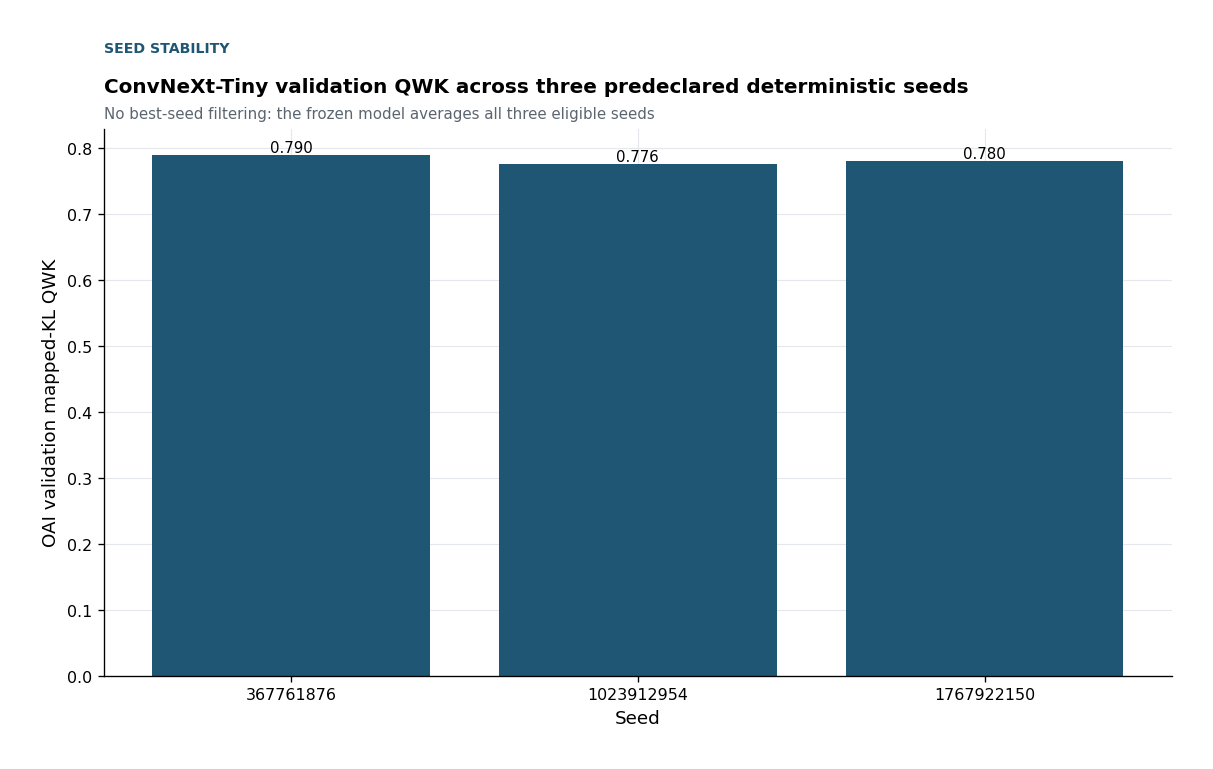

In [22]:



plot_data = candidate_metrics.sort_values("seed").copy()



fig, ax = plt.subplots(

    figsize=(9.5, 5.8),

    constrained_layout=True,

)



bars = ax.bar(

    plot_data["seed"].astype(str),

    plot_data["kl_qwk"],

    color=PRIMARY_COLOR,

)



ax.set_xlabel("Seed")

ax.set_ylabel("OAI validation mapped-KL QWK")



for bar, value in zip(bars, plot_data["kl_qwk"]):

    ax.text(

        bar.get_x() + bar.get_width() / 2,

        value,

        f"{value:.3f}",

        ha="center",

        va="bottom",

        fontsize=9,

    )



panel_title(

    ax,

    "Seed stability",

    "ConvNeXt-Tiny validation QWK across three predeclared deterministic seeds",

    "No best-seed filtering: the frozen model averages all three eligible seeds",

)



save_figure(

    fig,

    "N03_F01_backbone_selection",

)

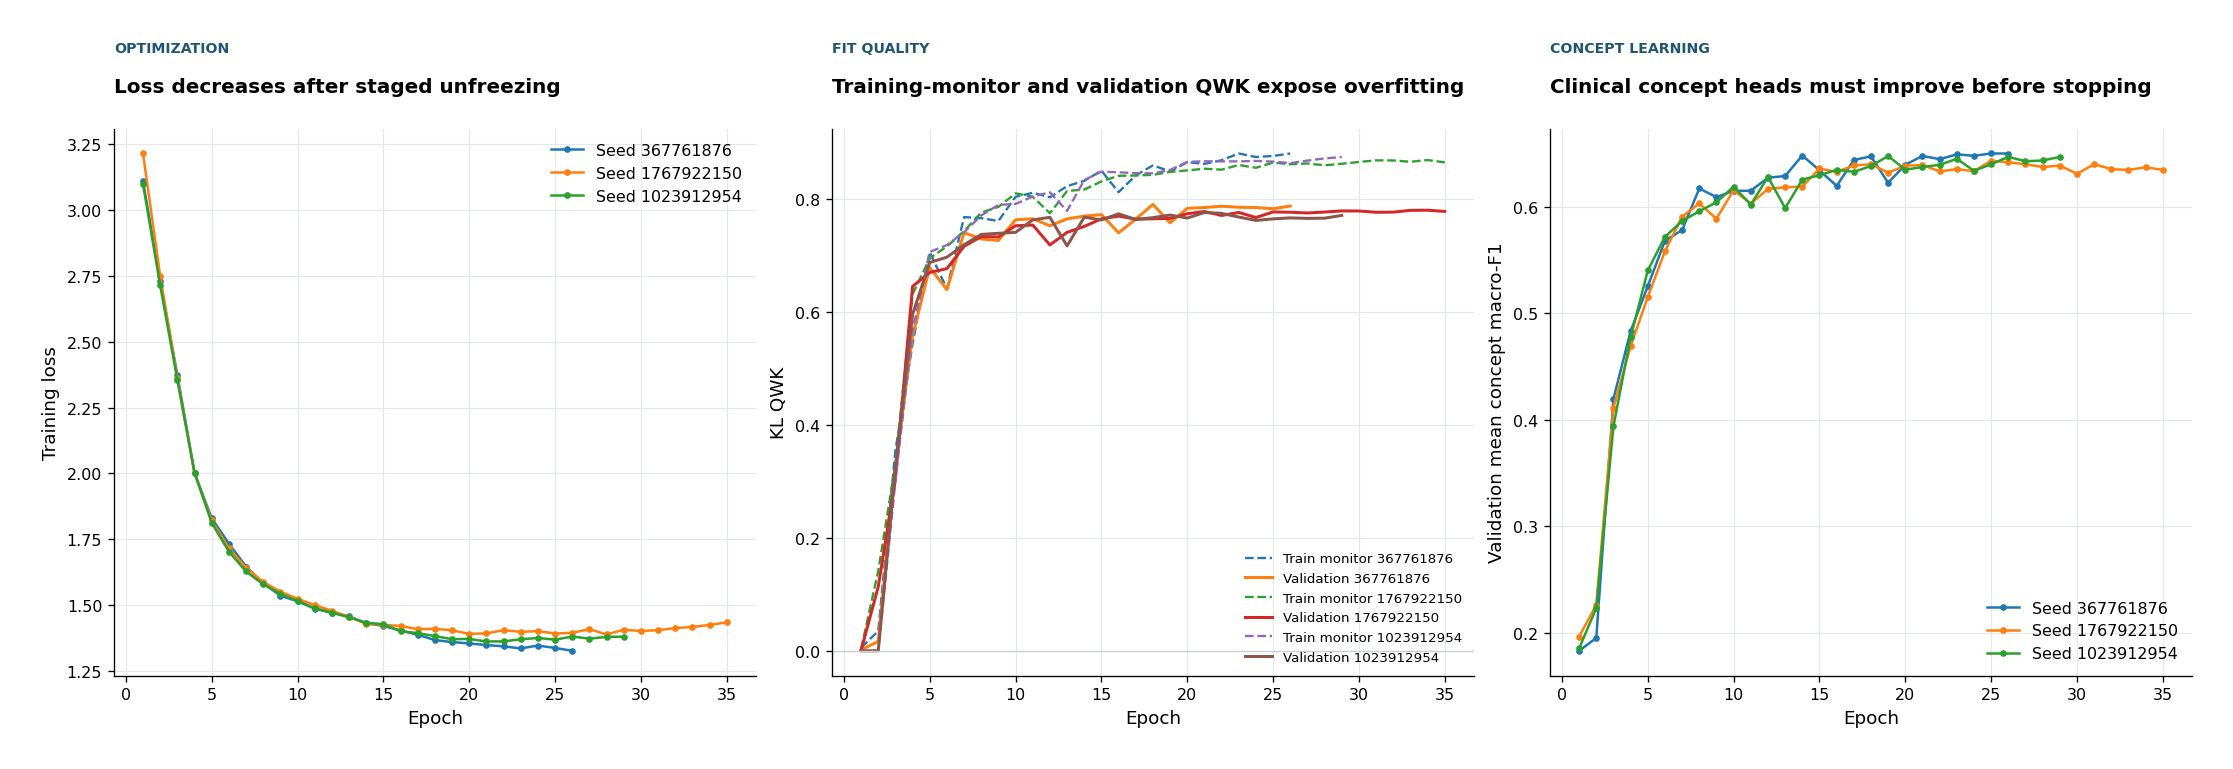

In [23]:



selected_history = (

    all_histories.loc[

        all_histories[

            "backbone"

        ].eq(PRIMARY_BACKBONE)

    ].copy()

)



fig, axes = plt.subplots(

    1,

    3,

    figsize=(18.0, 5.8),

    constrained_layout=True,

)



for seed in TRAINING_SEEDS:

    subset = selected_history.loc[

        selected_history["seed"].eq(

            seed

        )

    ]



    axes[0].plot(

        subset["epoch"],

        subset["train_loss"],

        marker="o",

        markersize=3,

        label=f"Seed {seed}",

    )



    axes[1].plot(

        subset["epoch"],

        subset["monitor_kl_qwk"],

        linestyle="--",

        linewidth=1.4,

        label=f"Train monitor {seed}",

    )

    axes[1].plot(

        subset["epoch"],

        subset["validation_kl_qwk"],

        linewidth=1.8,

        label=f"Validation {seed}",

    )



    axes[2].plot(

        subset["epoch"],

        subset[

            "validation_mean_concept_macro_f1"

        ],

        marker="o",

        markersize=3,

        label=f"Seed {seed}",

    )



axes[0].set_xlabel("Epoch")

axes[0].set_ylabel("Training loss")

axes[0].legend(loc="upper right")



axes[1].axhline(

    0,

    linewidth=0.8,

    color=HAIRLINE,

)

axes[1].set_xlabel("Epoch")

axes[1].set_ylabel("KL QWK")

axes[1].legend(

    loc="lower right",

    fontsize=8,

)



axes[2].set_xlabel("Epoch")

axes[2].set_ylabel(

    "Validation mean concept macro-F1"

)

axes[2].legend(loc="lower right")



panel_title(

    axes[0],

    "Optimization",

    "Loss decreases after staged unfreezing",

)



panel_title(

    axes[1],

    "Fit quality",

    "Training-monitor and validation QWK expose overfitting",

)



panel_title(

    axes[2],

    "Concept learning",

    "Clinical concept heads must improve before stopping",

)



save_figure(

    fig,

    "N03_F02_training_curves",

)

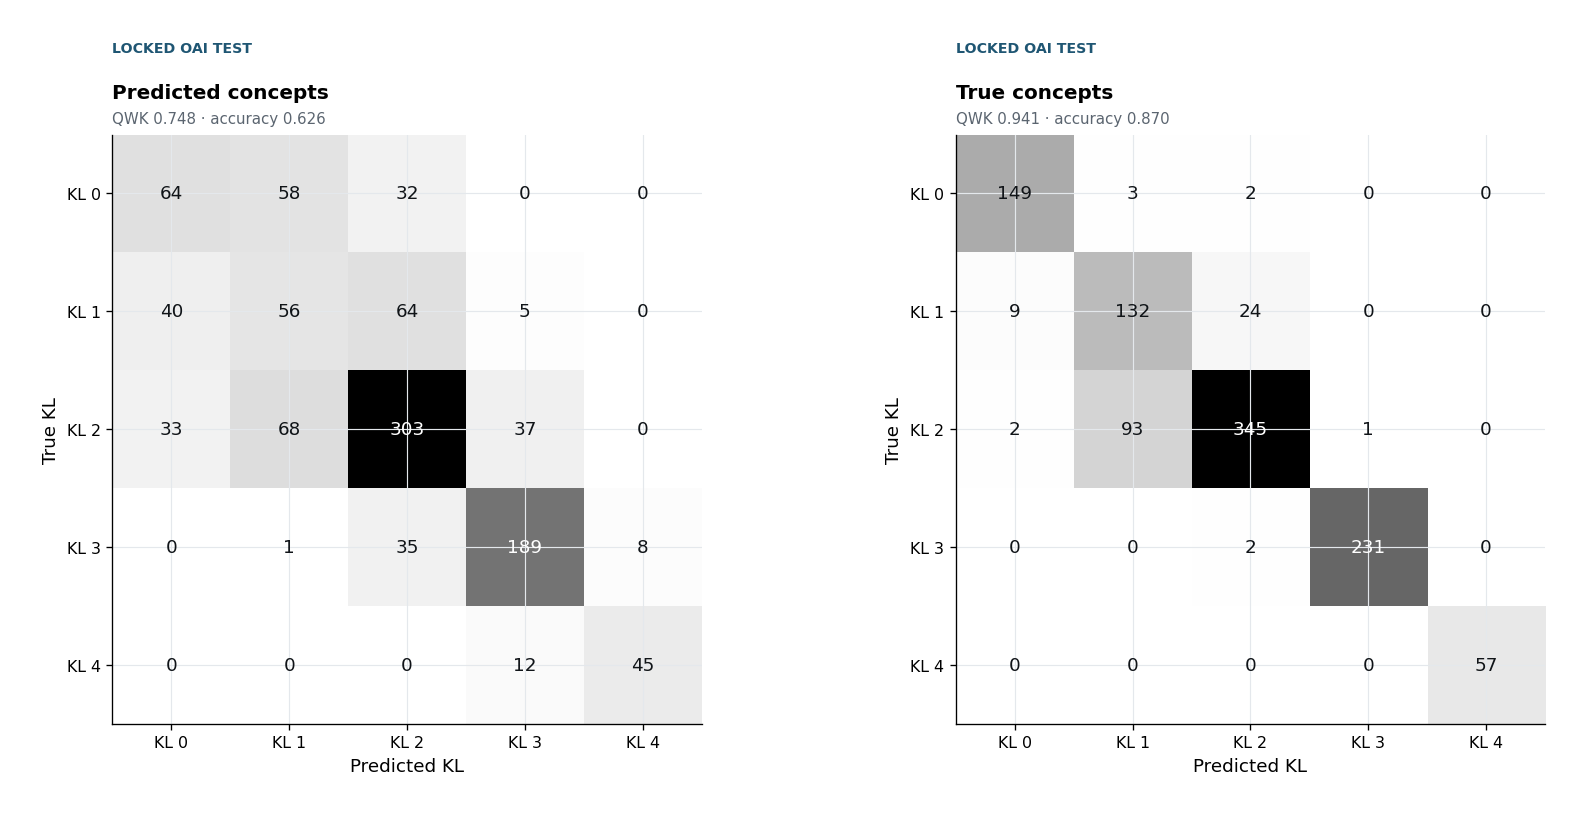

In [24]:



mapped_confusion = confusion_matrix(

    test_predictions["kl_grade"],

    test_predictions[

        "mapped_kl_prediction"

    ],

    labels=list(range(5)),

)



oracle_confusion = confusion_matrix(

    test_predictions["kl_grade"],

    test_predictions[

        "oracle_kl_prediction"

    ],

    labels=list(range(5)),

)



fig, axes = plt.subplots(

    1,

    2,

    figsize=(14.0, 6.2),

    constrained_layout=True,

)



for ax, matrix, title, metric_prefix in (

    (

        axes[0],

        mapped_confusion,

        "Predicted concepts",

        "kl",

    ),

    (

        axes[1],

        oracle_confusion,

        "True concepts",

        "oracle_kl",

    ),

):

    ax.imshow(

        matrix,

        cmap="Greys",

    )



    ax.set_xticks(

        range(5),

        [

            f"KL {grade}"

            for grade in range(5)

        ],

    )

    ax.set_yticks(

        range(5),

        [

            f"KL {grade}"

            for grade in range(5)

        ],

    )

    ax.set_xlabel("Predicted KL")

    ax.set_ylabel("True KL")



    threshold = matrix.max() * 0.55



    for row in range(5):

        for column in range(5):

            value = matrix[

                row,

                column,

            ]

            ax.text(

                column,

                row,

                f"{value:,}",

                ha="center",

                va="center",

                color=(

                    PAPER

                    if value > threshold

                    else INK

                ),

            )



    panel_title(

        ax,

        "Locked OAI test",

        title,

        (

            f"QWK "

            f"{test_metrics[f'{metric_prefix}_qwk']:.3f} · "

            f"accuracy "

            f"{test_metrics[f'{metric_prefix}_accuracy']:.3f}"

        ),

    )



save_figure(

    fig,

    "N03_F03_oai_test_confusion",

)



atomic_csv(

    pd.DataFrame(

        mapped_confusion,

        index=[

            f"true_{grade}"

            for grade in range(5)

        ],

        columns=[

            f"pred_{grade}"

            for grade in range(5)

        ],

    ).reset_index(),

    TABLES

    / "N03_T10_oai_test_mapped_confusion.csv",

)



atomic_csv(

    pd.DataFrame(

        oracle_confusion,

        index=[

            f"true_{grade}"

            for grade in range(5)

        ],

        columns=[

            f"pred_{grade}"

            for grade in range(5)

        ],

    ).reset_index(),

    TABLES

    / "N03_T11_oai_test_oracle_confusion.csv",

)

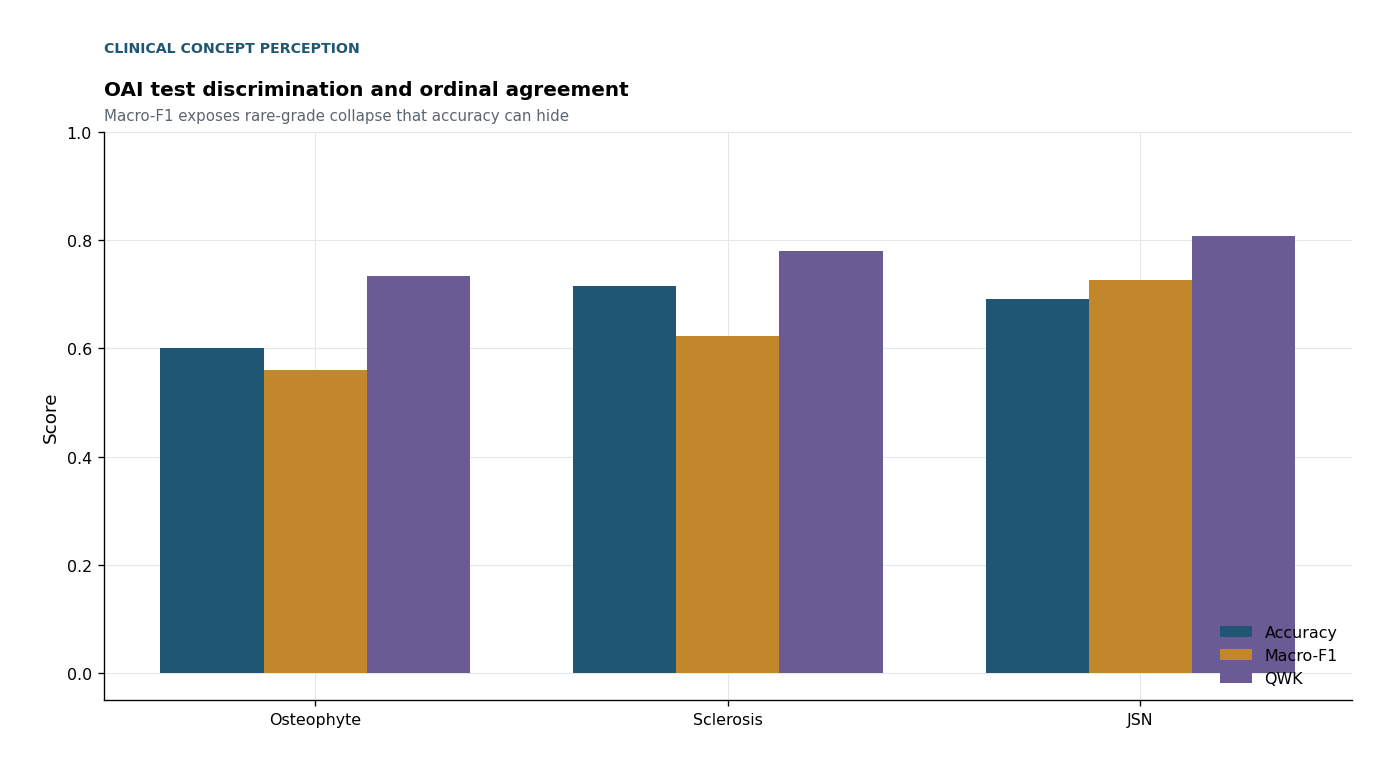

In [25]:



concept_plot_rows = []



for concept in TARGET_COLUMNS:

    concept_plot_rows.append({

        "concept": concept,

        "accuracy": test_metrics[

            f"{concept}_accuracy"

        ],

        "macro_f1": test_metrics[

            f"{concept}_macro_f1"

        ],

        "qwk": test_metrics[

            f"{concept}_qwk"

        ],

    })



concept_plot = pd.DataFrame(

    concept_plot_rows

)



x = np.arange(

    len(concept_plot)

)

width = 0.25



fig, ax = plt.subplots(

    figsize=(11.0, 5.8),

    constrained_layout=True,

)



ax.bar(

    x - width,

    concept_plot["accuracy"],

    width,

    label="Accuracy",

    color=PRIMARY_COLOR,

)

ax.bar(

    x,

    concept_plot["macro_f1"],

    width,

    label="Macro-F1",

    color=SECONDARY_COLOR,

)

ax.bar(

    x + width,

    concept_plot["qwk"],

    width,

    label="QWK",

    color=ACCENT_COLOR,

)



ax.set_xticks(

    x,

    [

        "Osteophyte",

        "Sclerosis",

        "JSN",

    ],

)

ax.set_ylim(-0.05, 1.0)

ax.set_ylabel("Score")

ax.legend(loc="lower right")



panel_title(

    ax,

    "Clinical concept perception",

    "OAI test discrimination and ordinal agreement",

    "Macro-F1 exposes rare-grade collapse that accuracy can hide",

)



save_figure(

    fig,

    "N03_F04_concept_performance",

)

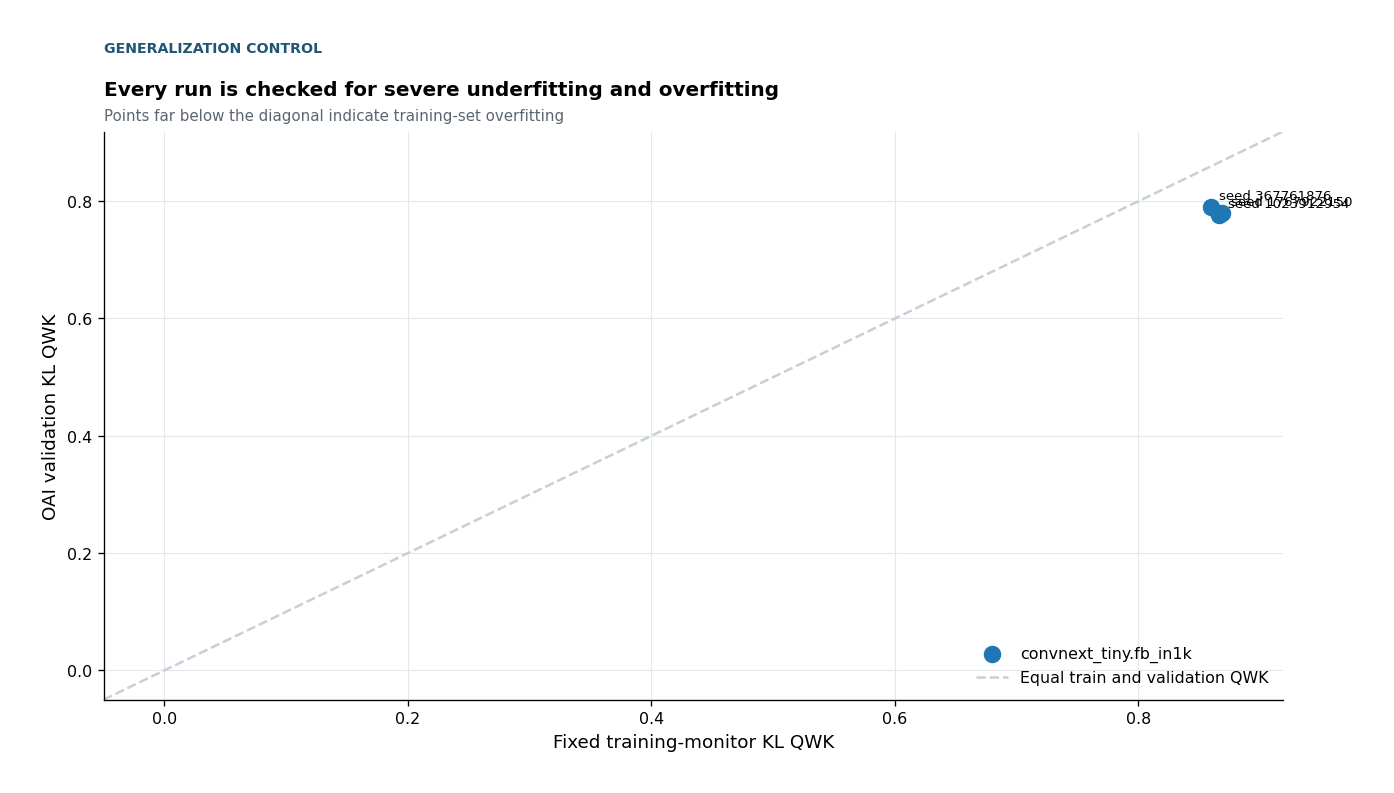

In [26]:



plot_data = fit_diagnostics.copy()



fig, ax = plt.subplots(

    figsize=(11.0, 6.0),

    constrained_layout=True,

)



markers = {

    "convnext_tiny.fb_in1k": "o",

}



for backbone, group in plot_data.groupby(

    "backbone"

):

    ax.scatter(

        group["train_monitor_kl_qwk"],

        group["validation_kl_qwk"],

        s=90,

        marker=markers.get(

            backbone,

            "o",

        ),

        label=backbone,

    )



    for row in group.itertuples(

        index=False

    ):

        ax.annotate(

            f"seed {row.seed}",

            (

                row.train_monitor_kl_qwk,

                row.validation_kl_qwk,

            ),

            xytext=(5, 5),

            textcoords="offset points",

            fontsize=8,

        )



limits = [

    min(

        plot_data[

            "train_monitor_kl_qwk"

        ].min(),

        plot_data[

            "validation_kl_qwk"

        ].min(),

        0,

    ) - 0.05,

    max(

        plot_data[

            "train_monitor_kl_qwk"

        ].max(),

        plot_data[

            "validation_kl_qwk"

        ].max(),

        0.2,

    ) + 0.05,

]



ax.plot(

    limits,

    limits,

    linestyle="--",

    color=HAIRLINE,

    label="Equal train and validation QWK",

)

ax.set_xlim(limits)

ax.set_ylim(limits)

ax.set_xlabel(

    "Fixed training-monitor KL QWK"

)

ax.set_ylabel(

    "OAI validation KL QWK"

)

ax.legend(loc="lower right")



panel_title(

    ax,

    "Generalization control",

    "Every run is checked for severe underfitting and overfitting",

    (

        "Points far below the diagonal indicate "

        "training-set overfitting"

    ),

)



save_figure(

    fig,

    "N03_F05_fit_diagnostics",

)

# 15. Freeze model and prediction manifests

In [27]:



checkpoint_manifest = pd.DataFrame([

    {

        "backbone": record["backbone"],

        "resolved_backbone": record[

            "resolved_backbone"

        ],

        "seed": int(record["seed"]),

        "selected_backbone": (

            record["backbone"]

            == PRIMARY_BACKBONE

        ),

        "eligible": (

            not record["collapsed"]

            and not record[

                "severe_underfit"

            ]

        ),

        "collapsed": bool(

            record["collapsed"]

        ),

        "severe_underfit": bool(

            record["severe_underfit"]

        ),

        "severe_overfit": bool(

            record["severe_overfit"]

        ),

        "checkpoint_path": record[

            "checkpoint_path"

        ],

        "checkpoint_sha256": record[

            "checkpoint_sha256"

        ],

        "best_epoch": int(

            record["best_epoch"]

        ),

        "validation_kl_qwk": float(

            record["kl_qwk"]

        ),

        "validation_concept_macro_f1": (

            float(

                record[

                    "mean_concept_macro_f1"

                ]

            )

        ),

        "validation_concept_qwk": float(

            record["mean_concept_qwk"]

        ),

        "qwk_generalization_gap": float(

            record[

                "qwk_generalization_gap"

            ]

        ),

    }

    for record in candidate_metrics.to_dict(

        orient="records"

    )

])



atomic_csv(

    checkpoint_manifest,

    MANIFESTS

    / "n03_checkpoint_manifest.csv",

)



prediction_manifest = {

    "created_utc": datetime.now(

        timezone.utc

    ).isoformat(),

    "stage": STAGE,

    "protocol": "Predeclared single-backbone protocol",

    "protocol_version": CONFIG.protocol_version,

    "checkpoint_io_policy": (

        "Save PyTorch archives locally, copy complete files to Drive, "

        "retry visibility and rename, then verify final byte size."

    ),

    "amp_overflow_policy": (

        "Skip isolated non-finite optimizer steps, reduce AMP scale, "

        "and fail only when the predefined persistence threshold is exceeded."

    ),

    "primary_backbone": PRIMARY_BACKBONE,

    "initialization": "ImageNet pretrained",

    "image_size": CONFIG.image_size,

    "num_workers": 0,

    "resume_training": CONFIG.resume_training,

    "running_ensemble_validation": {

        "path": str(TABLES / "N03_T05B_running_ensemble_validation.csv"),

        "sha256": sha256_file(TABLES / "N03_T05B_running_ensemble_validation.csv"),

    },

    "batch_size": BATCH_SIZE,

    "gradient_accumulation": GRADIENT_ACCUMULATION,

    "effective_batch_size": EFFECTIVE_BATCH_SIZE,

    "study_seed": CONFIG.study_seed,

    "training_seeds": list(TRAINING_SEEDS),

    "training_seed_generation": (

        "numpy.random.SeedSequence(study_seed).spawn(3)"

    ),

    "ensemble_rule": (

        "Equal arithmetic mean of validation-calibrated probabilities "

        "from all three eligible predeclared seeds"

    ),

    "seed_replacement_permitted": False,

    "best_seed_filtering_permitted": False,

    "training_stages": {

        "frozen_encoder_epochs": (

            CONFIG.frozen_encoder_epochs

        ),

        "fine_tuning": (

            "Full encoder with lower encoder LR"

        ),

        "true_mapping_supervision": True,

        "predicted_mapping_consistency": True,

        "weighted_sampler": False,

    },

    "calibration_dataset": (

        "OAI validation only"

    ),

    "external_cohort_loaded": False,

    "oai_predictions": {

        "path": str(

            OAI_PREDICTION_PATH

        ),

        "sha256": sha256_file(

            OAI_PREDICTION_PATH

        ),

        "seed_probability_path": str(

            PREDICTIONS

            / "n03_oai_seed_probabilities.npz"

        ),

        "seed_probability_sha256": (

            sha256_file(

                PREDICTIONS

                / "n03_oai_seed_probabilities.npz"

            )

        ),

    },

    "temperature_table": {

        "path": str(

            TABLES

            / "N03_T07_temperatures.csv"

        ),

        "sha256": sha256_file(

            TABLES

            / "N03_T07_temperatures.csv"

        ),

    },

}



atomic_json(

    prediction_manifest,

    MANIFESTS

    / "n03_prediction_manifest.json",

)

# 16. Acceptance certificate

N03 passes when:

- N01 passed;
- paper mode used a CUDA GPU;
- all six candidate runs completed;
- the primary backbone was selected on OAI validation only;
- exactly three selected checkpoints exist;
- temperatures were fitted on OAI validation;
- OAI predictions were exported;
- NHANES was not loaded or evaluated;
- all required Drive artifacts exist.

In [28]:



selected_checkpoint_rows = (

    checkpoint_manifest.loc[

        checkpoint_manifest[

            "selected_backbone"

        ]

        & checkpoint_manifest[

            "eligible"

        ]

    ]

)



selected_fit = fit_diagnostics.loc[

    fit_diagnostics["backbone"].eq(

        PRIMARY_BACKBONE

    )

]



criteria = {

    "N01 passed":

        n01_status.get("passed") is True,

    "paper mode used CUDA":

        RUN_MODE != "paper"

        or DEVICE.type == "cuda",

    "OAI split is patient-disjoint":

        not bool(

            train_ids & validation_ids

            or train_ids & test_ids

            or validation_ids & test_ids

        ),

    "weighted sampler was removed":

        True,

    "DataLoader multiprocessing is disabled":

        CONFIG.num_workers == 0,

    "Drive checkpoint write/read preflight passed":

        execution_preflight[

            "drive_checkpoint_write_read_test"

        ] == "PASS",

    "AMP overflow handling remained within tolerance":

        (

            all_histories[

                "train_skipped_nonfinite_fraction"

            ].fillna(0)

            <= CONFIG.maximum_nonfinite_gradient_fraction

        ).all(),

    "running ensemble validation covers one, two, and three seeds":

        running_ensemble_validation["completed_seeds"].tolist()

        == [1, 2, 3],

    "three unique deterministic training seeds were frozen":

        len(TRAINING_SEEDS) == 3

        and len(set(TRAINING_SEEDS)) == 3

        and SEED_MANIFEST_PATH.exists(),

    "all three ConvNeXt-Tiny runs completed":

        len(candidate_metrics)

        == len(TRAINING_SEEDS),

    "every predeclared training seed appears exactly once":

        sorted(

            candidate_metrics["seed"].astype(int).tolist()

        )

        == sorted(TRAINING_SEEDS),

    "no seed replacement or best-seed filtering occurred":

        len(selected_checkpoint_rows)

        == len(TRAINING_SEEDS),

    "all candidate runs predicted at least three KL classes":

        not candidate_metrics[

            "collapsed"

        ].any(),

    "no selected seed is severely underfit":

        not selected_fit[

            "severe_underfit"

        ].any(),

    "no selected seed is severely overfit":

        not selected_fit[

            "severe_overfit"

        ].any(),

    "ConvNeXt-Tiny has three eligible predeclared seeds":

        backbone_summary["seeds"].eq(

            len(TRAINING_SEEDS)

        ).all(),

    "the predefined backbone remained ConvNeXt-Tiny":

        PRIMARY_BACKBONE == "convnext_tiny.fb_in1k"

        and CONFIG.primary_backbone == "convnext_tiny.fb_in1k",

    "exactly three primary checkpoints exist":

        len(selected_checkpoint_rows)

        == len(TRAINING_SEEDS)

        and selected_checkpoint_rows[

            "checkpoint_path"

        ].map(

            lambda value: Path(

                value

            ).exists()

        ).all(),

    "all required temperatures were fitted":

        len(temperature_table)

        == len(TRAINING_SEEDS)

        * (

            3

            + len(TARGET_COLUMNS)

        ),

    "temperature scaling did not worsen validation NLL":

        bool((temperature_table["nll_after"] <= temperature_table["nll_before"] + 1e-5).all()),

    "OAI predictions cover every frozen OAI knee":

        len(OAI_PREDICTIONS)

        == len(OAI),

    "OAI prediction knee keys are unique":

        OAI_PREDICTIONS[

            "knee_key"

        ].is_unique,

    "paper mode completed":

        RUN_MODE == "paper",

}



passed = all(

    bool(value)

    for value in criteria.values()

)



status = {

    "stage": STAGE,

    "run_mode": RUN_MODE,

    "passed": passed,

    "criteria": {

        key: bool(value)

        for key, value in (

            criteria.items()

        )

    },

    "device": str(DEVICE),

    "gpu_name": GPU_NAME,

    "batch_size": BATCH_SIZE,

    "gradient_accumulation": GRADIENT_ACCUMULATION,

    "effective_batch_size": EFFECTIVE_BATCH_SIZE,

    "primary_backbone": (

        PRIMARY_BACKBONE

    ),

    "study_seed": CONFIG.study_seed,

    "training_seeds": list(TRAINING_SEEDS),

    "seed_manifest_sha256": sha256_file(SEED_MANIFEST_PATH),

    "fit_diagnostics": (

        selected_fit.to_dict(

            orient="records"

        )

    ),

    "oai_test_metrics": {

        key: float(value)

        for key, value in (

            test_metrics.items()

        )

    },

    "external_cohort_loaded": False,

    "primary_model_manifest_sha256": (

        sha256_file(

            PRIMARY_MODEL_PATH

        )

    ),

    "prediction_manifest_sha256": (

        sha256_file(

            MANIFESTS

            / "n03_prediction_manifest.json"

        )

    ),

}



STATUS_PATH = (

    RESULTS / "n03_status.json"

)



atomic_json(

    status,

    STATUS_PATH,

)



criteria_frame = pd.DataFrame({

    "criterion": list(

        criteria.keys()

    ),

    "pass": [

        bool(value)

        for value in (

            criteria.values()

        )

    ],

})



atomic_csv(

    criteria_frame,

    RESULTS

    / "n03_acceptance_criteria.csv",

)



certificate_lines = [

    "=" * 82,

    "N02A OAI-ONLY MODEL DEVELOPMENT CERTIFICATE",

    "=" * 82,

    f"Run mode: {RUN_MODE}",

    f"Device: {DEVICE}",

    f"Accelerator: {GPU_NAME}",

    f"Batch size: {BATCH_SIZE}",

    f"Gradient accumulation: {GRADIENT_ACCUMULATION}",

    f"Effective batch size: {EFFECTIVE_BATCH_SIZE}",

    (

        f"Notebook passed: "

        f"{'YES' if passed else 'NO'}"

    ),

    "",

]



for criterion, result in (

    criteria.items()

):

    label = textwrap.shorten(

        criterion,

        width=63,

        placeholder="…",

    )



    certificate_lines.append(

        f"{label:<65} "

        f"{'PASS' if result else 'FAIL'}"

    )



certificate_lines.extend([

    "",

    f"Primary backbone: {PRIMARY_BACKBONE}",

    f"Study seed: {CONFIG.study_seed}",

    f"Training seeds: {list(TRAINING_SEEDS)}",

    (

        f"OAI test mapped QWK: "

        f"{test_metrics['kl_qwk']:.4f}"

    ),

    (

        f"OAI test oracle-concept QWK: "

        f"{test_metrics['oracle_kl_qwk']:.4f}"

    ),

    (

        f"OAI test mapped accuracy: "

        f"{test_metrics['kl_accuracy']:.4f}"

    ),

    (

        f"OAI test concept macro-F1: "

        f"{test_metrics['mean_concept_macro_f1']:.4f}"

    ),

    "NHANES loaded in N02A: NO",

    "",

    (

        f"READY FOR N02B: "

        f"{'YES' if passed else 'NO'}"

    ),

    (

        f"READY FOR N03: "

        f"{'YES' if passed else 'NO'}"

    ),

    "=" * 82,

])



certificate = "\n".join(

    certificate_lines

)



print(certificate)



(

    RESULTS

    / "n03_validation_certificate.txt"

).write_text(

    certificate,

    encoding="utf-8",

)



display(criteria_frame)



if not passed:

    raise RuntimeError(

        "N03 did not pass. Repair only "

        "the failed validation criteria."

    )

N02A OAI-ONLY MODEL DEVELOPMENT CERTIFICATE
Run mode: paper
Device: cuda
Accelerator: NVIDIA A100-SXM4-80GB
Batch size: 24
Gradient accumulation: 1
Effective batch size: 24
Notebook passed: YES

N01 passed                                                        PASS
paper mode used CUDA                                              PASS
OAI split is patient-disjoint                                     PASS
weighted sampler was removed                                      PASS
DataLoader multiprocessing is disabled                            PASS
Drive checkpoint write/read preflight passed                      PASS
AMP overflow handling remained within tolerance                   PASS
running ensemble validation covers one, two, and three seeds      PASS
three unique deterministic training seeds were frozen             PASS
all three ConvNeXt-Tiny runs completed                            PASS
every predeclared training seed appears exactly once              PASS
no seed replacement or b

,criterion,pass
0,N01 passed,True
1,paper mode used CUDA,True
2,OAI split is patient-disjoint,True
3,weighted sampler was removed,True
4,DataLoader multiprocessing is disabled,True
5,Drive checkpoint write/read preflight passed,True
6,AMP overflow handling remained within tolerance,True
7,"running ensemble validation covers one, two, a...",True
8,three unique deterministic training seeds were...,True
9,all three ConvNeXt-Tiny runs completed,True


# 17. Strict Google Drive save audit

In [29]:





from pathlib import Path

from datetime import datetime, timezone

import hashlib

import json

import shutil








FINAL_ROOT = Path(

    "/content/drive/MyDrive/MasterThesis/Final Pipeline"

)



CHECKPOINT_DIR = FINAL_ROOT / "checkpoints" / "N02A"

RESULT_DIR = FINAL_ROOT / "results" / "N02A"

TABLE_DIR = FINAL_ROOT / "tables" / "N02A"

FIGURE_DIR = FINAL_ROOT / "figures" / "N02A"

PREDICTION_DIR = FINAL_ROOT / "predictions" / "N02A"

MANIFEST_DIR = FINAL_ROOT / "manifests" / "N02A"



for folder in (

    CHECKPOINT_DIR,

    RESULT_DIR,

    TABLE_DIR,

    FIGURE_DIR,

    PREDICTION_DIR,

    MANIFEST_DIR,

):

    folder.mkdir(

        parents=True,

        exist_ok=True,

    )



PROTOCOL = "N02A_RETRAINED"

NOTEBOOK_NAME = "N02A_OAI_Only_Primary_CBM.ipynb"










def sha256_file(

    path: Path,

) -> str:

    digest = hashlib.sha256()



    with path.open("rb") as handle:

        for block in iter(

            lambda: handle.read(1024 * 1024),

            b"",

        ):

            digest.update(block)



    return digest.hexdigest()





def copy_verified(

    source_path: Path,

    destination_path: Path,

) -> None:

    if (

        not source_path.exists()

        or source_path.stat().st_size == 0

    ):

        raise RuntimeError(

            f"Missing or empty source artifact: {source_path}"

        )



    destination_path.parent.mkdir(

        parents=True,

        exist_ok=True,

    )



    temporary_path = destination_path.with_suffix(

        destination_path.suffix + ".tmp"

    )



    if temporary_path.exists():

        temporary_path.unlink()



    shutil.copy2(

        source_path,

        temporary_path,

    )



    if (

        sha256_file(source_path)

        != sha256_file(temporary_path)

    ):

        temporary_path.unlink(

            missing_ok=True

        )

        raise RuntimeError(

            f"Copy verification failed: {source_path}"

        )



    temporary_path.replace(

        destination_path

    )










checkpoint_rows = []



for seed in TRAINING_SEEDS:

    source_path = (

        CHECKPOINTS

        / (

            f"{CONFIG.primary_backbone}"

            f"_seed{seed}_best.pt"

        )

    )



    destination_path = (

        CHECKPOINT_DIR

        / (

            f"convnext_tiny_seed{seed}.pt"

        )

    )



    copy_verified(

        source_path,

        destination_path,

    )



    checkpoint_rows.append({

        "backbone": CONFIG.primary_backbone,

        "seed": int(seed),

        "checkpoint_path": str(destination_path),

        "size_bytes": int(

            destination_path.stat().st_size

        ),

        "size_mb": round(

            destination_path.stat().st_size

            / 1024**2,

            2,

        ),

        "sha256": sha256_file(

            destination_path

        ),

        "frozen_utc": datetime.now(

            timezone.utc

        ).isoformat(),

    })





checkpoint_manifest = pd.DataFrame(

    checkpoint_rows

)



atomic_csv(

    checkpoint_manifest,

    MANIFEST_DIR / "checkpoint_manifest.csv",

)



atomic_json(

    {

        "stage": "N02A",

        "protocol": PROTOCOL,

        "backbone": CONFIG.primary_backbone,

        "training_seeds": [

            int(seed)

            for seed in TRAINING_SEEDS

        ],

        "checkpoint_directory": str(

            CHECKPOINT_DIR

        ),

        "checkpoint_count": int(

            len(checkpoint_manifest)

        ),

        "frozen_utc": datetime.now(

            timezone.utc

        ).isoformat(),

    },

    MANIFEST_DIR / "freeze_metadata.json",

)



display(

    checkpoint_manifest

)










for seed in TRAINING_SEEDS:

    source_path = (

        RESULTS

        / (

            f"n03_history_"

            f"{CONFIG.primary_backbone}"

            f"_seed{seed}.csv"

        )

    )



    destination_path = (

        RESULT_DIR

        / f"history_seed{seed}.csv"

    )



    copy_verified(

        source_path,

        destination_path,

    )










table_map = {

    TABLES / "N03_T04_candidate_metrics.csv":

        TABLE_DIR / "T01_candidate_metrics.csv",



    TABLES / "N03_T05_fit_diagnostics.csv":

        TABLE_DIR / "T02_fit_diagnostics.csv",



    TABLES / "N03_T05B_running_ensemble_validation.csv":

        TABLE_DIR / "T03_running_validation.csv",



    TABLES / "N03_T07_temperatures.csv":

        TABLE_DIR / "T04_temperatures.csv",



    TABLES / "N03_T08_oai_test_metrics.csv":

        TABLE_DIR / "T05_oai_metrics.csv",



    TABLES / "N03_T09_oai_test_per_class_metrics.csv":

        TABLE_DIR / "T06_per_class_metrics.csv",

}





for source_path, destination_path in table_map.items():

    copy_verified(

        source_path,

        destination_path,

    )










prediction_map = {

    PREDICTIONS / "n03_oai_predictions.csv":

        PREDICTION_DIR / "oai_predictions.csv",



    PREDICTIONS / "n03_oai_seed_probabilities.npz":

        PREDICTION_DIR / "oai_probabilities.npz",

}





for source_path, destination_path in (

    prediction_map.items()

):

    copy_verified(

        source_path,

        destination_path,

    )










figure_map = {

    "N03_F01_backbone_selection":

        "F01_backbone_selection",



    "N03_F02_training_curves":

        "F02_training_curves",



    "N03_F03_oai_test_confusion":

        "F03_confusion_matrix",



    "N03_F04_concept_performance":

        "F04_concepts",



    "N03_F05_fit_diagnostics":

        "F05_fit_diagnostics",

}





for source_stem, destination_stem in (

    figure_map.items()

):

    for extension in (

        "png",

        "pdf",

    ):

        source_path = (

            FIGURES

            / f"{source_stem}.{extension}"

        )



        destination_path = (

            FIGURE_DIR

            / f"{destination_stem}.{extension}"

        )



        copy_verified(

            source_path,

            destination_path,

        )










expected_results = [

    f"history_seed{seed}.csv"

    for seed in TRAINING_SEEDS

]



expected_tables = [

    "T01_candidate_metrics.csv",

    "T02_fit_diagnostics.csv",

    "T03_running_validation.csv",

    "T04_temperatures.csv",

    "T05_oai_metrics.csv",

    "T06_per_class_metrics.csv",

]



expected_figures = [

    f"{stem}.{extension}"

    for stem in figure_map.values()

    for extension in (

        "png",

        "pdf",

    )

]



expected_predictions = [

    "oai_predictions.csv",

    "oai_probabilities.npz",

]



expected_checkpoints = [

    f"convnext_tiny_seed{seed}.pt"

    for seed in TRAINING_SEEDS

]



expected_manifests = [

    "checkpoint_manifest.csv",

    "freeze_metadata.json",

]





audit_rows = []



for category, folder, filenames in (

    (

        "result",

        RESULT_DIR,

        expected_results,

    ),

    (

        "table",

        TABLE_DIR,

        expected_tables,

    ),

    (

        "figure",

        FIGURE_DIR,

        expected_figures,

    ),

    (

        "prediction",

        PREDICTION_DIR,

        expected_predictions,

    ),

    (

        "checkpoint",

        CHECKPOINT_DIR,

        expected_checkpoints,

    ),

    (

        "manifest",

        MANIFEST_DIR,

        expected_manifests,

    ),

):

    for filename in filenames:

        path = folder / filename



        audit_rows.append({

            "category": category,

            "file": filename,

            "exists": path.exists(),

            "nonempty": (

                path.exists()

                and path.stat().st_size > 0

            ),

            "size_bytes": (

                path.stat().st_size

                if path.exists()

                else None

            ),

            "sha256": (

                sha256_file(path)

                if (

                    path.exists()

                    and path.stat().st_size > 0

                )

                else None

            ),

            "path": str(path),

        })





drive_audit = pd.DataFrame(

    audit_rows

)



atomic_csv(

    drive_audit,

    RESULT_DIR / "drive_save_audit.csv",

)



all_artifacts_present = bool(

    drive_audit["nonempty"].all()

)










manifest_rows = []



for folder in (

    RESULT_DIR,

    TABLE_DIR,

    FIGURE_DIR,

    PREDICTION_DIR,

    CHECKPOINT_DIR,

    MANIFEST_DIR,

):

    for path in sorted(

        folder.glob("*")

    ):

        if not path.is_file():

            continue



        manifest_rows.append({

            "path": str(

                path.relative_to(

                    FINAL_ROOT

                )

            ),

            "bytes": int(

                path.stat().st_size

            ),

            "modified_utc": (

                datetime.fromtimestamp(

                    path.stat().st_mtime,

                    tz=timezone.utc,

                ).isoformat()

            ),

            "sha256": sha256_file(

                path

            ),

            "generator": NOTEBOOK_NAME,

            "protocol": PROTOCOL,

        })





output_manifest = pd.DataFrame(

    manifest_rows

)



atomic_csv(

    output_manifest,

    MANIFEST_DIR / "output_manifest.csv",

)










criteria = {

    "three checkpoints frozen":

        len(checkpoint_manifest)

        == len(TRAINING_SEEDS),



    "all checkpoint hashes exist":

        bool(

            checkpoint_manifest[

                "sha256"

            ].notna().all()

        ),



    "all required artifacts are present":

        all_artifacts_present,



    "all final paths use the new pipeline root":

        drive_audit[

            "path"

        ].str.startswith(

            str(FINAL_ROOT)

        ).all(),

}





criteria_table = pd.DataFrame([

    {

        "criterion": criterion,

        "passed": bool(passed),

    }

    for criterion, passed in criteria.items()

])



atomic_csv(

    criteria_table,

    RESULT_DIR / "acceptance_criteria.csv",

)



passed = bool(

    criteria_table["passed"].all()

)



status = {

    "stage": "N02A",

    "protocol": PROTOCOL,

    "passed": passed,

    "checkpoint_directory": str(

        CHECKPOINT_DIR

    ),

    "results_directory": str(

        RESULT_DIR

    ),

    "tables_directory": str(

        TABLE_DIR

    ),

    "figures_directory": str(

        FIGURE_DIR

    ),

    "predictions_directory": str(

        PREDICTION_DIR

    ),

    "manifests_directory": str(

        MANIFEST_DIR

    ),

    "created_utc": datetime.now(

        timezone.utc

    ).isoformat(),

}



atomic_json(

    status,

    RESULT_DIR / "status.json",

)



certificate_lines = [

    "=" * 78,

    "N02A MODEL FREEZE CERTIFICATE",

    "=" * 78,

]



for criterion, criterion_passed in (

    criteria.items()

):

    certificate_lines.append(

        (

            "PASS  "

            if criterion_passed

            else "FAIL  "

        )

        + criterion

    )



certificate_lines.extend([

    "",

    f"Protocol: {PROTOCOL}",

    f"Checkpoint directory: {CHECKPOINT_DIR}",

    "Legacy pipeline dependency: NO",

    (

        "FINAL STATUS: PASS"

        if passed

        else "FINAL STATUS: FAIL"

    ),

    (

        "READY FOR N02B: YES"

        if passed

        else "READY FOR N02B: NO"

    ),

    "=" * 78,

])



certificate = "\n".join(

    certificate_lines

)



(

    RESULT_DIR / "certificate.txt"

).write_text(

    certificate,

    encoding="utf-8",

)



display(

    drive_audit

)



display(

    criteria_table

)



print()

print(certificate)



if not passed:

    missing = drive_audit.loc[

        ~drive_audit["nonempty"],

        "path",

    ].tolist()



    if missing:

        print("\nMissing artifacts:")

        for path in missing:

            print(" -", path)



    raise RuntimeError(

        "N02A freeze or output audit failed."

    )



print()

print("N02A FREEZE COMPLETE")

,category,file,exists,size_bytes,sha256,path
0,result,environment.json,True,2494,48224f35df219e7080dc65c7f046a546170bb5714c6084...,/content/drive/MyDrive/Master Thesis/thesis/re...
1,result,n03_execution_preflight.json,True,888,426c3877195718dfab02d0ee7079fc3d28d392933ed48e...,/content/drive/MyDrive/Master Thesis/thesis/re...
2,result,n03_all_training_histories.csv,True,350128,ad1d31133b8dafdb90cc1dd621c14c0a6d49f14f64a63f...,/content/drive/MyDrive/Master Thesis/thesis/re...
3,result,n03_acceptance_criteria.csv,True,1071,b38c93312b2961e66f35ae3f17f01d64a649c4d17fa894...,/content/drive/MyDrive/Master Thesis/thesis/re...
4,result,n03_status.json,True,8848,001ac50ac510f027a8ac8993b3f2ee3f6ebd28682053c2...,/content/drive/MyDrive/Master Thesis/thesis/re...
5,result,n03_validation_certificate.txt,True,2387,ffb1bcf5be1edc4b88d4066e584fe52e13434169acf000...,/content/drive/MyDrive/Master Thesis/thesis/re...
6,result,n03_history_convnext_tiny.fb_in1k_seed36776187...,True,106169,94bbf7ccd0d20af1de9ad905d84912a5e2b9c5612acc56...,/content/drive/MyDrive/Master Thesis/thesis/re...
7,result,n03_history_convnext_tiny.fb_in1k_seed17679221...,True,140993,9e381eb327bdf6cc4ebb67491d38175b4c4b4dfdb764cc...,/content/drive/MyDrive/Master Thesis/thesis/re...
8,result,n03_history_convnext_tiny.fb_in1k_seed10239129...,True,117242,6f12add7090a899a8f924ec5f38433e0c988b91d76827a...,/content/drive/MyDrive/Master Thesis/thesis/re...
9,table,N03_T01_oai_split.csv,True,77,9b200f1a6a25203a2cb35d356d67a5822d040520bbdffa...,/content/drive/MyDrive/Master Thesis/thesis/ta...



N02A GOOGLE DRIVE SAVE AUDIT
Results: /content/drive/MyDrive/Master Thesis/thesis/results/N03
Figures: /content/drive/MyDrive/Master Thesis/thesis/figures/N03
Tables: /content/drive/MyDrive/Master Thesis/thesis/tables/N03
Checkpoints: /content/drive/MyDrive/Master Thesis/thesis/checkpoints/N03
Predictions: /content/drive/MyDrive/Master Thesis/thesis/predictions/N03
Manifests: /content/drive/MyDrive/Master Thesis/thesis/manifests

ALL REQUIRED N03 RESULTS, FIGURES, TABLES, CHECKPOINTS, PREDICTIONS, AND MANIFESTS ARE PRESENT.
Final N03 status passed: True
